CONTENTS:
- [Exploratory Data Analysis: FRED Metadata](#exploratory-data-analysis:-fred-metadata)
  - [Contents](#contents)
  - [Introduction](#introduction)
  - [Import necessary Packages and load the Metadata](#import-necessary-packages-and-load-the-metadata)
    - [Column information](#column-information)
  - [Preprocessing](#preprocessing)
  - [Introductory Analytics](#introductory-analytics)
    - [Missing Data](#missing-data)
    - [Descriptor Analytics](#descriptor-analytics)
    - [Top Data Sources](#top-data-sources)
  - [Data Freshness](#data-freshness)
    - [Start/End Cohorts by Decade](#start/end-cohorts-by-decade)
    - [Discontinued Series](#discontinued-series)
    - [Active/Discontinued by Source](#active/discontinued-by-source)
    - [Top 20 Discontinued by Data Source](#top-20-discontinued-by-data-source)
    - [Top 20 Discontinued by Tag](#top-20-discontinued-by-tag)
    - [Top 20 Discontinued by Category](#top-20-discontinued-by-category)
    - [Frequency of Data](#frequency-of-data)
    - [Base Frequency by Data Source](#base-frequency-by-data-source)
  - [Seasonal Adjustment Analysis](#seasonal-adjustment-analysis)
  - [Analyses on Categories and Tags](#analyses-on-categories-and-tags)
    - [Categories Distribution](#categories-distribution)
    - [Tags Distribution](#tags-distribution)
    - [Count of Tags and Categories per Series](#count-of-tags-and-categories-per-series)
    - [Co-occurance of the Top 20 Tags with the Top 20 Categories](#co-occurance-of-the-top-20-tags-with-the-top-20-categories)
  - [Geographical Analysis](#geographical-analysis)
    - [US vs Non-US](#us-vs-non-us)
    - [Breakdown by Continent](#breakdown-by-continent)
    - [Distribution of Data by State](#distribution-of-data-by-state)
  - [Analyses of some Derived Features](#analyses-of-some-derived-features)
    - [Derived Feature Correlation](#derived-feature-correlation)
    - [Duration vs Staleness](#duration-vs-staleness)

<a name='exploratory-data-analysis:-fred-metadata'></a>
# Exploratory Data Analysis: FRED Metadata

<a name='contents'></a>
## Contents

- [Introduction](#introduction)
- [Import necessary Packages and load the Metadata](#import-necessary-packages-and-load-the-metadata)
  - [Column information](#column-information)

- [Preprocessing](#preprocessing)

- [Introductory Analytics](#introductory-analytics)
    - [Missing Data](#missing-data)
    - [Descriptor Analytics](#descriptor-analytics)
    - [Top Data Sources](#top-data-sources)

- [Data Freshness](#data-freshness)
    - [Start/End Cohorts by Decade](#startend-cohorts-by-decade)
    - [Discontinued Series](#discontinued-series)
    - [Active vs. Discontinued by Source](#activevs-discontinued-by-source)
    - [Top 20 Discontinued by Data Source](#top-20-discontinued-by-data-source)
    - [Top 20 Discontinued by Tag](#top-20-discontinued-by-tag)
    - [Top 20 Discontinued by Category](#top-20-discontinued-by-category)
    - [Overall Frequency Distribution](#frequency-distribution-by-base-frequency)
    - [Non‑Dominant Frequency Distribution](#non-dominant-frequency-distribution)
    - [Base Frequency by Data Source (Top 20)](#data-source-vs-base-frequency-top-20-sources)
    - [Base Frequency by Data Source (Non‑dominant)](#data-source-vs-base-frequency-non-dominant-sources)

- [Seasonal Adjustment Distribution](#seasonal-adjustment-distribution)

- [Analyses of Categories and Tags](#analyses-on-categories-and-tags)
    - [Categories Distribution](#categories-distribution)
    - [Tags Distribution](#tags-distribution)
    - [Count of Tags and Categories per Series](#count-of-tags-and-categories-per-series)
    - [Tag–Category Co‑occurrence Heatmap](#tag–category-co-occurrence)

- [Geographical Analysis](#geographical-analysis)
    - [US vs Non‑US Data](#us-vs-non-us-data)
    - [Series by Continent](#series-by-continent)
    - [Distribution in Non‑Dominant Continents](#distribution-in-non-dominant-continents)
    - [Choropleth: Series Count by State](#choropleth-series-count-by-state)

- [Analysis of some Derived Features](#analyses-of-some-derived-features)
    - [Feature Correlation](#feature-correlation)
    - [Duration vs. Staleness](#duration-vs-staleness)

---


<a name='introduction'></a>
## Introduction

This notebook draws statistical insights from the metadata of the Federdal Reserve Economic Database. The goal is to get a full picture of what data is available on FRED. It performs a suite of exploratory analyses on `s3://causify-data-collaborators/causal_automl/metadata/fred_series_metadata.csv`, including tag/category distributions, temporal and geographic breakdowns, source comparisons, and more.

<a name='import-necessary-packages-and-load-the-metadata'></a>
## Import necessary Packages and load the Metadata

In [1]:
# Import required packages.
%load_ext autoreload
%autoreload 2
import json
import textwrap

import helpers.hs3 as hs3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
from matplotlib.ticker import FuncFormatter

# Notebook styling
sns.set_theme(style="whitegrid")

In [2]:
# Load metadata.
s3 = hs3.get_s3fs("ck")
file_path = "s3://causify-data-collaborators/causal_automl/metadata/fred_series_metadata.csv"
stream = s3.open(file_path, mode="r")

fred = pd.read_csv(stream, engine="python", on_bad_lines="skip")

In [3]:
print(fred.shape)
print(fred.columns)
fred.head(5)

(642162, 13)
Index(['id', 'title', 'description', 'tags', 'last_updated', 'units',
       'frequency', 'seasonal_adjustment', 'notes', 'categories',
       'data_source', 'start_date', 'end_date'],
      dtype='object')


,id,title,description,tags,last_updated,units,frequency,seasonal_adjustment,notes,categories,data_source,start_date,end_date
0,NROU,Noncyclical Rate of Unemployment,Graph and download economic data for Noncyclic...,nairu; cbo; long-term; projection; unemploymen...,2025-03-17T15:44:00-05:00,Percent,Quarterly,Not Seasonally Adjusted,"Starting with the July, 2021 report:An Update ...","Population, Employment, & Labor Markets",U.S. Congressional Budget Office,1949-01-01,2035-10-01
1,NROUST,Natural Rate of Unemployment (Short-Term) (DIS...,Graph and download economic data for Natural R...,nairu; cbo; short-term; projection; discontinu...,2021-02-01T14:37:00-06:00,Percent,Quarterly,Not Seasonally Adjusted,"This series last appeared in the February, 202...","Population, Employment, & Labor Markets",U.S. Congressional Budget Office,1949-01-01,2031-10-01
2,LNU04032183,Unemployment Rate - Asian,Graph and download economic data for Unemploym...,asian; 16 years +; household survey; unemploym...,2025-03-07T07:46:00-06:00,Percent,Monthly,Not Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",U.S. Bureau of Labor Statistics,2000-01-01,2025-03-01
3,U4RATE,"Total Unemployed Plus Discouraged Workers, as ...",Graph and download economic data for Total Une...,discouraged; labor underutilization; workers; ...,2025-03-07T07:46:00-06:00,Percent,Monthly,Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",U.S. Bureau of Labor Statistics,1994-01-01,2025-03-01
4,LNS14000025,"Unemployment Rate - 20 Yrs. & over, Men",Graph and download economic data for Unemploym...,20 years +; males; household survey; unemploym...,2025-03-07T07:48:00-06:00,Percent,Monthly,Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",U.S. Bureau of Labor Statistics,1948-01-01,2025-03-01


<a name='column-information'></a>
### Column information

| Column                | Description                                                      |
|-----------------------|------------------------------------------------------------------|
| `id`                | Unique FRED series identifier (e.g. “NROU”).                     |
| `title`             | Human‐readable name of the series.                               |
| `description`       | Full text describing what the series measures.                   |
| `tags`              | Semicolon‑separated keywords associated with the series.         |
| `last_updated`      | Timestamp of the most recent metadata update for this series.    |
| `units`             | Units of measurement (e.g. “Percent”, “USD”).                    |
| `frequency`         | Reporting frequency (e.g. “Monthly”, “Quarterly”, etc.).         |
| `seasonal_adjustment` | Indicates whether data are seasonally adjusted (e.g. “SA” or “Not Seasonally Adjusted”). |
| `notes`             | Additional commentary or caveats about the series.               |
| `categories`        | Semicolon‑separated high‑level classification(s) of the series.  |
| `data_source`       | Originating agency or organization that publishes the data.      |
| `start_date`        | Date of the first observation available for the series.          |
| `end_date`          | Date of the last (or most recent forecasted) observation.        |


<a name='preprocessing'></a>
## Preprocessing

To get useful insights, the dataset is first processed, with the data standardized and some new columns derived. The raw CSV is first loaded with all fields as strings, then the key date columns are converted into proper timestamps and any timezone info is removed. We split out tags and categories into list columns, count how many each series has, and flag those marked “discontinued.” We also derive how long it’s been since each series was updated, bucket update and start/end years for easy grouping, and compute roughly how many years each series spans. This gives us a clean, consistent table ready for analysis.

In [4]:
# Parse all date columns, and base frequencies
# last_updated: ISO with timezone → UTC → drop tzinfo.
fred["last_updated"] = pd.to_datetime(
    fred["last_updated"], utc=True, errors="coerce"
).dt.tz_convert(None)
# start_date & end_date: simple YYYY-MM-DD → datetime, invalid → NaT.
fred["start_date"] = pd.to_datetime(
    fred["start_date"], format="%Y-%m-%d", errors="coerce"
)
fred["end_date"] = pd.to_datetime(
    fred["end_date"], format="%Y-%m-%d", errors="coerce"
)
fred["freq_base"] = (
    fred["frequency"]
    .fillna("Not Available")
    .str.split(pat=",", n=1)  # specify n by name
    .str[0]
)

In [5]:
# Split tags & categories, count them, and flag discontinuations.
# Expand semicolon-separated strings into Python lists.
fred["tags_list"] = fred["tags"].str.split(";")
fred["categories_list"] = (
    fred["categories"]
    .fillna("")  # avoid None
    .str.split(";")  # split on ;
    .apply(
        lambda L: [  # strip + title‑case
            c.strip().title() for c in L if c.strip()
        ]
    )
)
# Count number of tags/categories per series.
fred["n_tags"] = fred["tags_list"].str.len()
fred["n_categories"] = fred["categories_list"].str.len()
# Flag any series tagged as 'discontinued' (case-insensitive).
fred["is_discontinued"] = fred["tags_list"].apply(
    lambda lst: any(
        str(tag).strip().lower() == "discontinued" for tag in (lst or [])
    )
)

In [6]:
# Compute staleness, year/decade buckets, and duration in years.
# Today's date (normalized to midnight).
today = pd.Timestamp.today().normalize()
# Days since last_updated.
fred["staleness_days"] = (today - fred["last_updated"]).dt.days
# Extract calendar years.
fred["last_year"] = fred["last_updated"].dt.year
fred["start_year"] = fred["start_date"].dt.year
fred["end_year"] = fred["end_date"].dt.year
fred["start_decade"] = (fred["start_year"] // 10) * 10
fred["end_decade"] = (fred["end_year"] // 10) * 10
# Vectorized duration: retain only where both dates are valid.
mask = fred["start_date"].notna() & fred["end_date"].notna()
dur_days = (
    fred.loc[mask, "end_date"].values.astype("datetime64[D]")
    - fred.loc[mask, "start_date"].values.astype("datetime64[D]")
).astype(int)
# Assign duration in years.
fred["duration_years"] = np.nan
fred.loc[mask, "duration_years"] = dur_days / 365.0

In [7]:
# Preprocessing: Infer country & continent from text fields
# Load country → continent mapping.
cc = pd.read_csv("country_continent.csv")
cc["Country_Name"] = cc["Country_Name"].str.strip()
cc["Continent_Name"] = cc["Continent_Name"].str.strip()
country2cont = dict(zip(cc["Country_Name"], cc["Continent_Name"]))


# Scan tags, title, description, notes for any exact country match.
def infer_country_from_text(row):
    for tag in row.get("tags_list") or []:
        t = str(tag).strip()
        if t in country2cont:
            return t
    for field in ["title", "description", "notes"]:
        for word in str(row.get(field, "")).split():
            w = word.strip(",.()")
            if w in country2cont:
                return w
    return np.nan


# Apply to create a 'country' column.
fred["country"] = fred.apply(infer_country_from_text, axis=1)
# Map country → continent, defaulting missing to 'Other'.
fred["continent"] = fred["country"].map(country2cont).fillna("Other")

In [8]:
# Preprocessing: Lengths of Descriptors
fred["title_len"] = fred["title"].str.len()
fred["desc_len"] = fred["description"].str.len()
fred["notes_len"] = fred["notes"].str.len()
# Quick sanity check.
fred.head()

,id,title,description,tags,last_updated,units,frequency,seasonal_adjustment,notes,categories,...,start_year,end_year,start_decade,end_decade,duration_years,country,continent,title_len,desc_len,notes_len
0,NROU,Noncyclical Rate of Unemployment,Graph and download economic data for Noncyclic...,nairu; cbo; long-term; projection; unemploymen...,2025-03-17 20:44:00,Percent,Quarterly,Not Seasonally Adjusted,"Starting with the July, 2021 report:An Update ...","Population, Employment, & Labor Markets",...,1949.0,2035,1940.0,2030,86.805479,United States of America,North America,32,165,819.0
1,NROUST,Natural Rate of Unemployment (Short-Term) (DIS...,Graph and download economic data for Natural R...,nairu; cbo; short-term; projection; discontinu...,2021-02-01 20:37:00,Percent,Quarterly,Not Seasonally Adjusted,"This series last appeared in the February, 202...","Population, Employment, & Labor Markets",...,1949.0,2031,1940.0,2030,82.802740,United States of America,North America,56,192,865.0
2,LNU04032183,Unemployment Rate - Asian,Graph and download economic data for Unemploym...,asian; 16 years +; household survey; unemploym...,2025-03-07 13:46:00,Percent,Monthly,Not Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",...,2000.0,2025,2000.0,2020,25.180822,United States of America,North America,25,174,103.0
3,U4RATE,"Total Unemployed Plus Discouraged Workers, as ...",Graph and download economic data for Total Une...,discouraged; labor underutilization; workers; ...,2025-03-07 13:46:00,Percent,Monthly,Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",...,1994.0,2025,1990.0,2020,31.183562,United States of America,North America,114,304,103.0
4,LNS14000025,"Unemployment Rate - 20 Yrs. & over, Men",Graph and download economic data for Unemploym...,20 years +; males; household survey; unemploym...,2025-03-07 13:48:00,Percent,Monthly,Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",...,1948.0,2025,1940.0,2020,77.216438,United States of America,North America,39,192,103.0


<a name='introductory-analytics'></a>
## Introductory Analytics

<a name='missing-data'></a>
### Missing Data

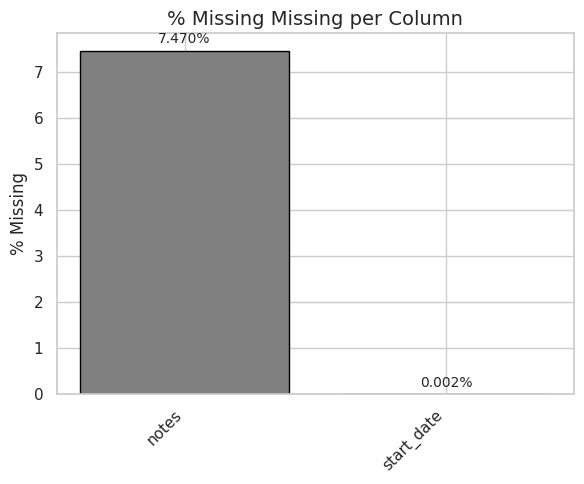

In [9]:
# Exclude computed columns.
original_cols = pd.Index(
    [
        "id",
        "title",
        "description",
        "tags",
        "last_updated",
        "units",
        "frequency",
        "seasonal_adjustment",
        "notes",
        "categories",
        "data_source",
        "start_date",
        "end_date",
    ]
)
# Compute percent missing per original column.
miss = fred[original_cols].isna().mean() * 100
# Keep only columns with any missingness.
miss = miss[miss > 0].sort_values(ascending=False)
# Plot bar chart.
plt.figure(figsize=(max(6, len(miss) * 1.2), 5))
bars = plt.bar(miss.index, miss.values, color="gray", edgecolor="black")
# Annotate.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.3f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.ylabel("% Missing", fontsize=12)
plt.title("% Missing Missing per Column", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Aside from the optional notes field, the dataset has got essentially full coverage across all other metadata columns—so downstream analyses won’t be materially impacted by missing values.

<a name='descriptor-analytics'></a>
### Descriptor Analytics

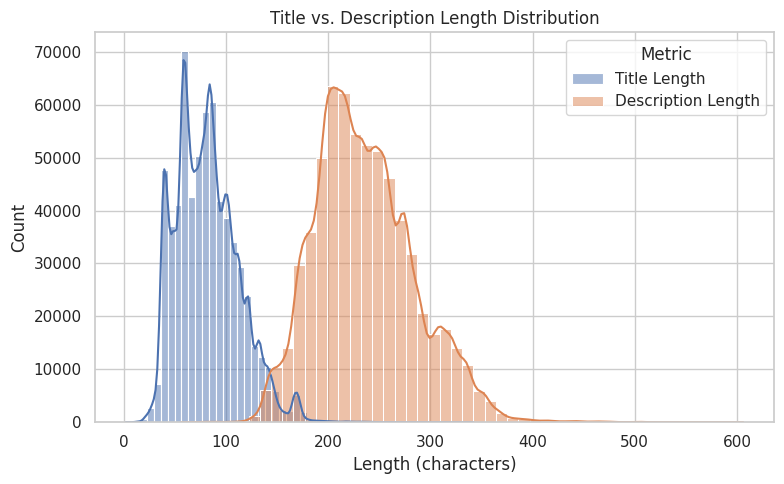

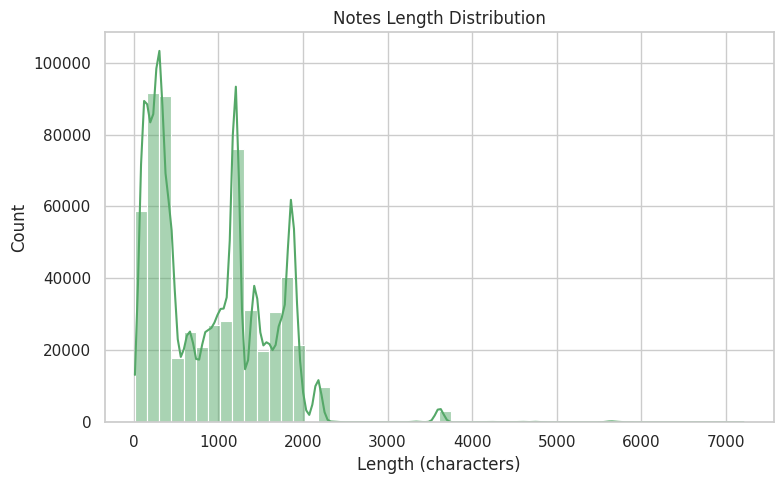

In [10]:


# Plot title and description lengths together.
plt.figure(figsize=(8, 5))
sns.histplot(
    fred["title_len"], bins=50, kde=True, color="C0", label="Title Length"
)
sns.histplot(
    fred["desc_len"], bins=50, kde=True, color="C1", label="Description Length"
)
plt.legend(title="Metric")
plt.title("Title vs. Description Length Distribution")
plt.xlabel("Length (characters)")
plt.tight_layout()
plt.show()
# Plot notes length separately.
plt.figure(figsize=(8, 5))
sns.histplot(fred["notes_len"], bins=50, kde=True, color="C2")
plt.title("Notes Length Distribution")
plt.xlabel("Length (characters)")
plt.tight_layout()
plt.show()


- **Titles are short and consistent:** Almost all series titles fall between **30–150 characters**, peaking around **70–100 chars**.

- **Descriptions are longer:** Descriptions peak in the **200-250 char** range, with a right‑skew into a **400+ char** tail.

- **Notes are highly variable:** Most notes stay under **2,000 chars**, but a significant number stretch into **multiple‑thousand‑char** territory; combined with ~**7.5% missingness**


<a name='top-data-sources'></a>
### Top Data Sources

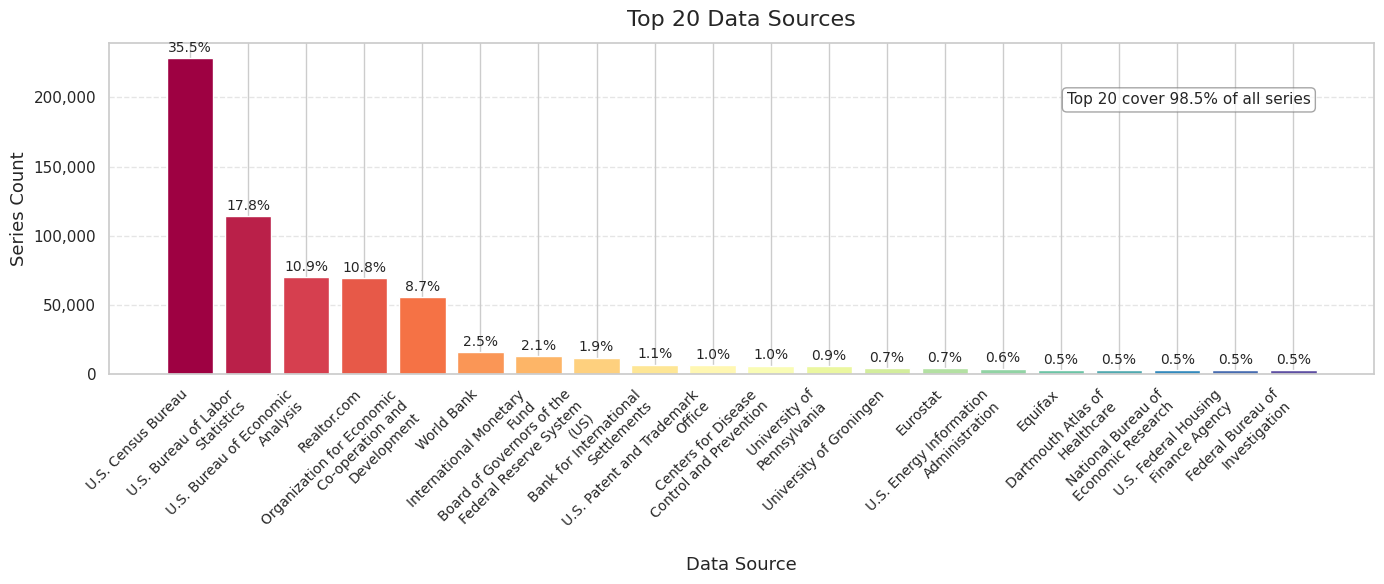

In [11]:
# Prepare data.
src_total = fred["data_source"].value_counts()
top20 = src_total.head(20)
labels = top20.index.tolist()
counts = top20.values
total = src_total.sum()
coverage_pct = counts.sum() / total * 100
wrapped = [textwrap.fill(lbl, width=25) for lbl in labels]
# Plot.
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
colors = plt.cm.Spectral(np.linspace(0, 1, len(labels)))
x = np.arange(len(labels))
bars = ax.bar(x, counts, color=colors, edgecolor="white", linewidth=1)
# Annotate.
for bar, c in zip(bars, counts):
    pct = c / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        c + counts.max() * 0.01,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
# Add Coverage.
note = f"Top 20 cover {coverage_pct:.1f}% of all series"
ax.text(
    0.95,
    0.85,
    note,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)
ax.set_xticks(x)
ax.set_xticklabels(wrapped, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Series Count", fontsize=13)
ax.set_xlabel("Data Source", fontsize=13)
ax.set_title("Top 20 Data Sources", fontsize=16, pad=12)
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

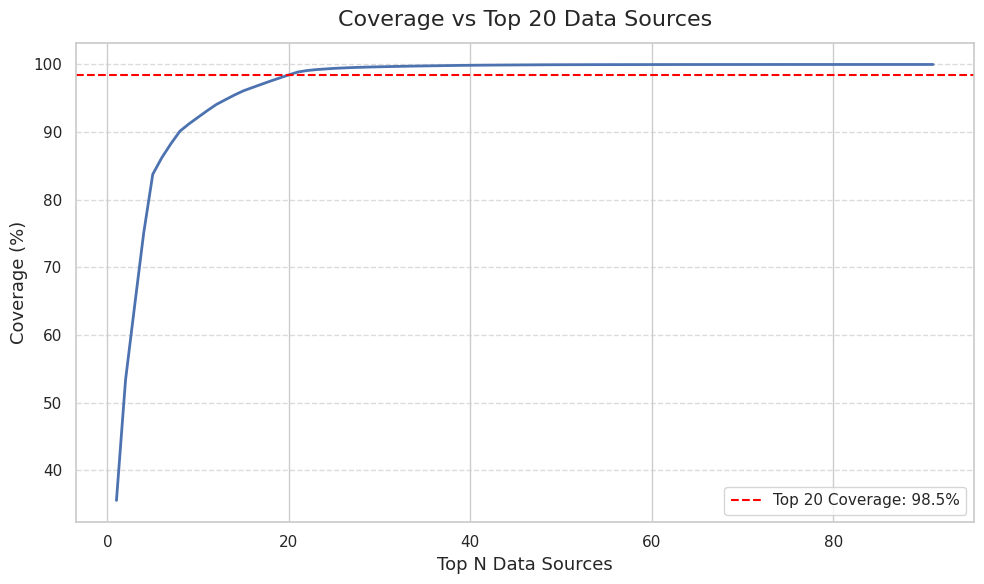

In [12]:
# Compute cumulative coverage for data sources.
N = 20
src_counts = fred["data_source"].value_counts()
cum_coverage = (
    src_counts.sort_values(ascending=False).cumsum() / src_counts.sum() * 100
)
# Plot coverage vs. top N data sources.
n_src = np.arange(1, len(cum_coverage) + 1)
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.plot(n_src, cum_coverage.values, linewidth=2)
# Highlight the Top N cutoff.
cutoff = cum_coverage.iloc[N - 1]
ax.axhline(
    cutoff, color="red", linestyle="--", label=f"Top {N} Coverage: {cutoff:.1f}%"
)
ax.set_xlabel("Top N Data Sources", fontsize=13)
ax.set_ylabel("Coverage (%)", fontsize=13)
ax.set_title(f"Coverage vs Top {N} Data Sources", fontsize=16, pad=12)
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

- **U.S.‑centric dominance (Unsurprising)**
  The top two sources are both major U.S. agencies: the U.S. Census Bureau (~35.5% of all series) and the Bureau of Labor Statistics (~17.8%). Together they supply over half of the entire database.

- **Heavy skew toward a handful of providers**
  The top five sources (adding the Bureau of Economic Analysis, Realtor.com, and the World Bank) contribute nearly 80% of all series. Beyond those, each additional source accounts for less than 11%.

- **Long but very shallow tail**
  Although 20 sources are shown, after the first handful the individual shares quickly drop below 3% each—and the smallest still make up only about 0.5% apiece.

- **Top 20 cover almost the whole universe**
  These 20 providers account for about **98.5%** of every series in the metadata, meaning there are very few “minor” suppliers beyond this group.

<a name='data-freshness'></a>
## Data Freshness

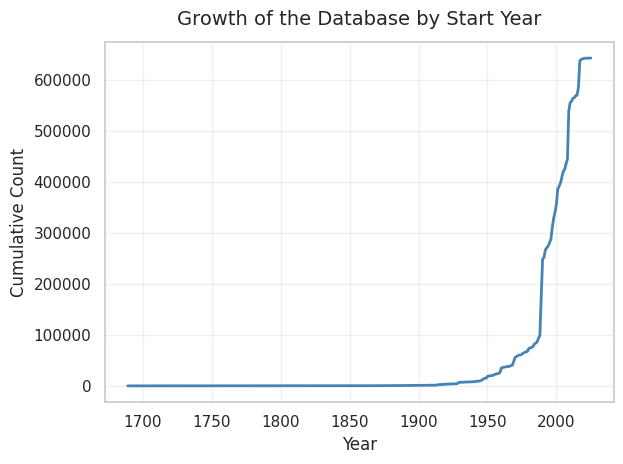

In [13]:
# Plot growth by start year.
cum = fred.groupby("start_year").size().sort_index().cumsum()
cum.plot(color="steelblue", linewidth=2)
plt.title("Growth of the Database by Start Year", pad=12, fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Cumulative Count", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

- **Slow beginnings:** Very little data from 1700 through roughly 1950 were added.
- **Mid‑century pickup:** Between 1950 and 1980 there’s a steady climb, reflecting growing data collection efforts in history.
- **Digital‐era explosion:** After 1980 the curve steepens, and especially post‑2000 it shoots up to over 600 000 series—driven by electronic data releases, globalization of sources, and API availability. The dataset’s breadth is overwhelmingly a product of recent decades; most series are relatively “young.”

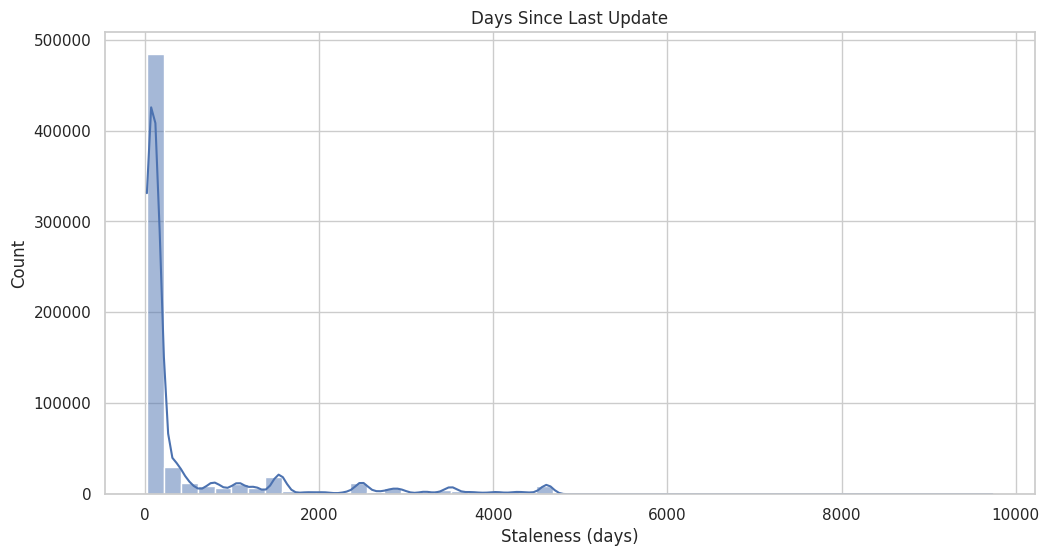

In [14]:
# Plot staleness by days
plt.figure(figsize=(12, 6))
sns.histplot(fred["staleness_days"], bins=50, kde=True)
plt.title("Days Since Last Update")
plt.xlabel("Staleness (days)")
plt.show()

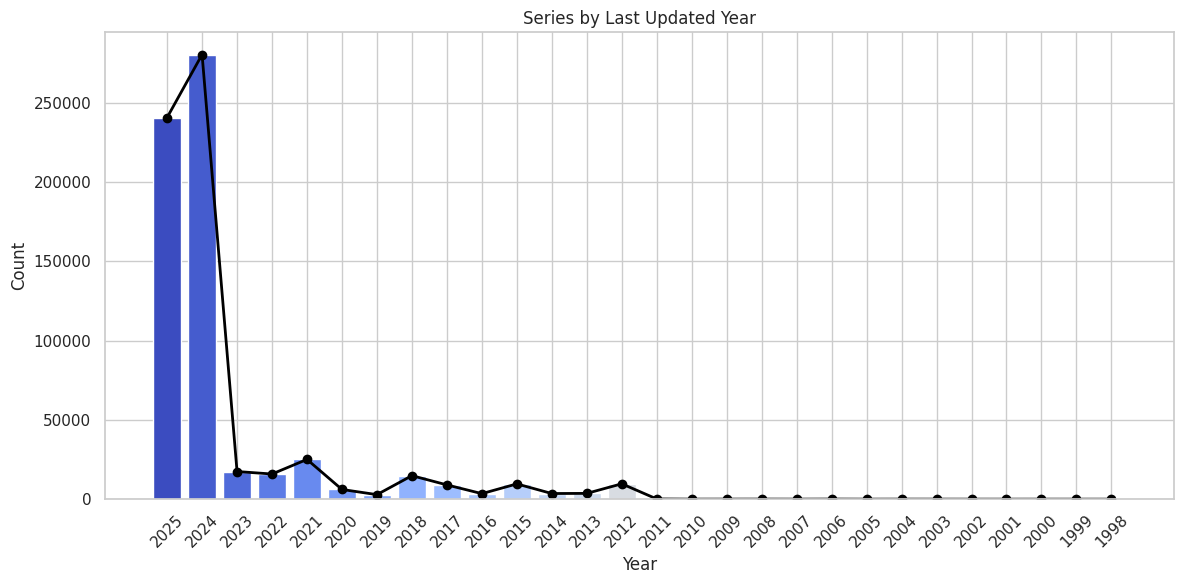

In [15]:
# Plot staleness by year.
# Prepare the data.
yrs = fred["last_year"].value_counts().sort_index(ascending=False)
years = yrs.index.astype(str)
counts = yrs.values
colors = plt.cm.coolwarm(np.linspace(0, 1, len(years)))
# Plot.
plt.figure(figsize=(12, 6))
plt.bar(years, counts, color=colors, edgecolor="white", linewidth=1)
plt.plot(years, counts, color="black", linewidth=2, marker="o")
plt.title("Series by Last Updated Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- **Fresh majority:** A huge spike near zero days indicates that most series are updated very recently (e.g. within weeks or months).
- **Heavy tail:** There are a long tail of series with thousands of days since last update—these are largely discontinued or legacy series.
- **But most data remain current, validating FRED as a live data source.**



<a name='start/end-cohorts-by-decade'></a>
### Start/End Cohorts by Decade

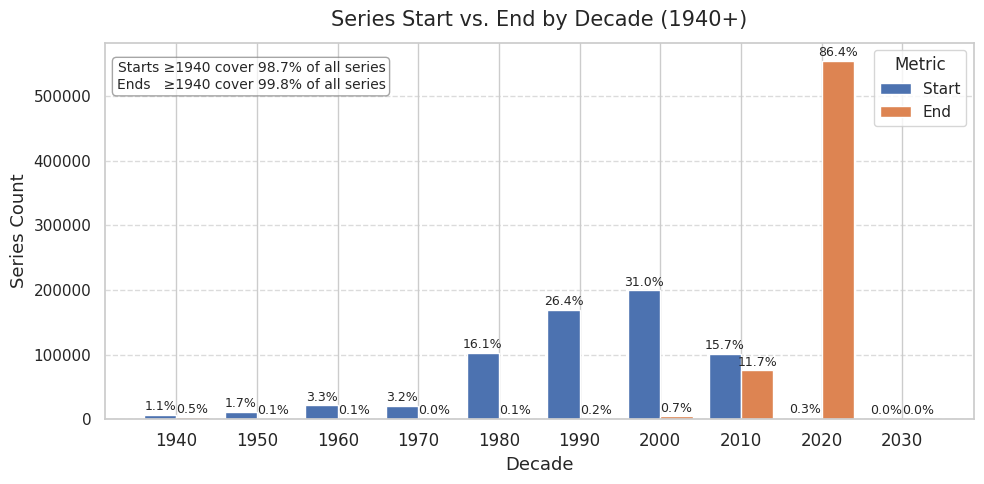

In [16]:
# Prepare data.
start_counts = fred["start_decade"].value_counts().sort_index()
end_counts = fred["end_decade"].value_counts().sort_index()
df_decade = (
    pd.DataFrame({"Started": start_counts, "Ended": end_counts})
    .fillna(0)
    .astype(int)
)
# Filter ≥1940.
df_plot = df_decade.loc[df_decade.index >= 1940]
total_started = df_decade["Started"].sum()
total_ended = df_decade["Ended"].sum()
pct_started_40p = df_plot["Started"].sum() / total_started * 100
pct_ended_40p = df_plot["Ended"].sum() / total_ended * 100
# Plot.
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
bar_width = 0.4
x = np.arange(len(df_plot.index))
bars_start = ax.bar(
    x - bar_width / 2,
    df_plot["Started"],
    width=bar_width,
    label="Start",
    color="C0",
    edgecolor="white",
)
bars_end = ax.bar(
    x + bar_width / 2,
    df_plot["Ended"],
    width=bar_width,
    label="End",
    color="C1",
    edgecolor="white",
)
# Annotate.
for bar in bars_start:
    pct = bar.get_height() / total_started * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + df_plot.values.max() * 0.005,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
for bar in bars_end:
    pct = bar.get_height() / total_ended * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + df_plot.values.max() * 0.005,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index.astype(int), fontsize=12)
ax.set_xlabel("Decade", fontsize=13)
ax.set_ylabel("Series Count", fontsize=13)
ax.set_title("Series Start vs. End by Decade (1940+)", fontsize=15, pad=12)
ax.legend(title="Metric")
note = (
    f"Starts ≥1940 cover {pct_started_40p:.1f}% of all series\n"
    f"Ends   ≥1940 cover {pct_ended_40p:.1f}% of all series"
)
ax.text(
    0.323,
    0.95,
    note,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

- **Modern‐Era Focus**
  Over 98% of all series began in 1940 or later, and nearly 75% started between 1980 and 2000, reflecting FRED’s rapid expansion in recent decades.

- **Peak Series Introductions**
  The 2000s saw the highest share of new series (≈31%), followed by the 1990s (≈26%). Earlier decades (1940–1970) each contributed only 1–3%.

- **Tapering New Additions**
  After 2000, the rate of new series slows: the 2010s account for ≈16%, and the 2020s almost none (<1%), suggesting FRED has matured.

- **End‐Date Concentration**
  End dates cluster overwhelmingly in the 2020s (≈86%), indicating most series remain active up through data collected in 2020.

- **Ongoing Data Availability**
  The spike in 2020 end dates implies that the vast majority of series are still maintained beyond that year; very few series have truly “ended.”

<a name='discontinued-series'></a>
### Discontinued Series

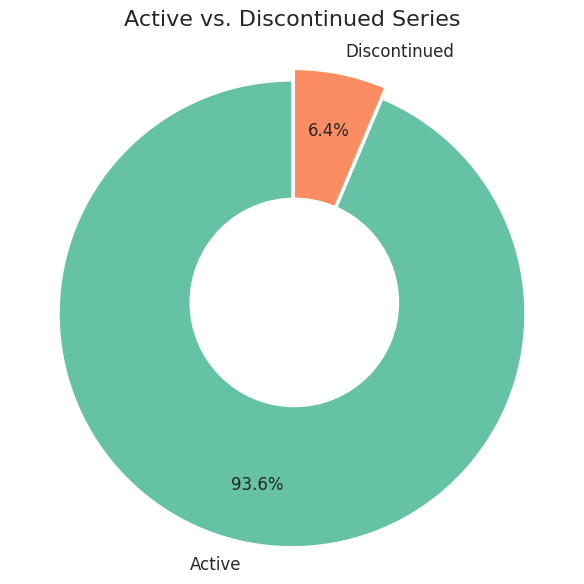

In [17]:

# Compute status counts
status = fred["is_discontinued"].value_counts()
labels = ["Active", "Discontinued"]
sizes = [status.get(False, 0), status.get(True, 0)]
# Plot donut graph.
plt.figure(figsize=(6, 6))
colors = plt.cm.Set2(np.arange(len(sizes)))
explode = (0.05, 0)
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    colors=colors,
    explode=explode,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
    textprops={"fontsize": 12},
)
centre_circle = plt.Circle((0, 0), 0.45, fc="white", linewidth=0)
plt.gca().add_artist(centre_circle)
plt.title("Active vs. Discontinued Series", fontsize=16, pad=20)
plt.axis("equal")
plt.tight_layout()
plt.show()

<a name='active/discontinued-by-source'></a>
### Active/Discontinued by Source

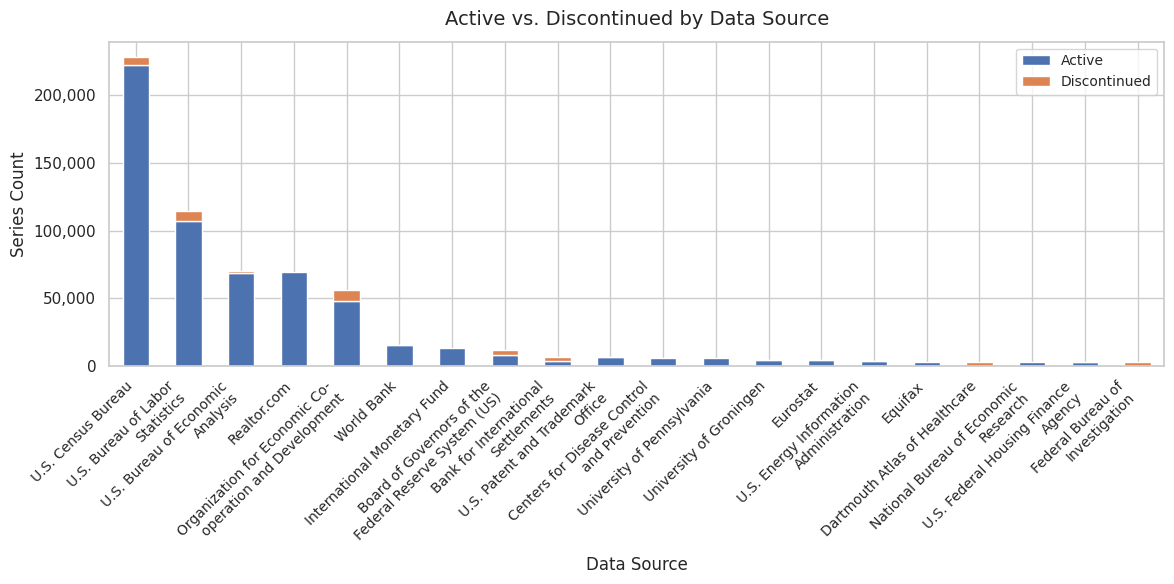

In [18]:
# Prepare data.
ds = fred.groupby(["data_source", "is_discontinued"]).size().unstack(fill_value=0)
top20_sources = fred["data_source"].value_counts().head(20).index.tolist()
ds_top20 = ds.reindex(top20_sources).fillna(0)
wrapped_labels = [textwrap.fill(src, width=30) for src in top20_sources]
# Plot.
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
ds_top20.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["C0", "C1"],  # blue=active, orange=discontinued
    edgecolor="white",
    linewidth=1,
    legend=True,
)
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right", fontsize=10)
ax.set_xlabel("Data Source", fontsize=12)
ax.set_ylabel("Series Count", fontsize=12)
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
ax.set_title("Active vs. Discontinued by Data Source", fontsize=14, pad=12)
ax.legend(["Active", "Discontinued"], title="", loc="upper right", fontsize=10)
fig.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

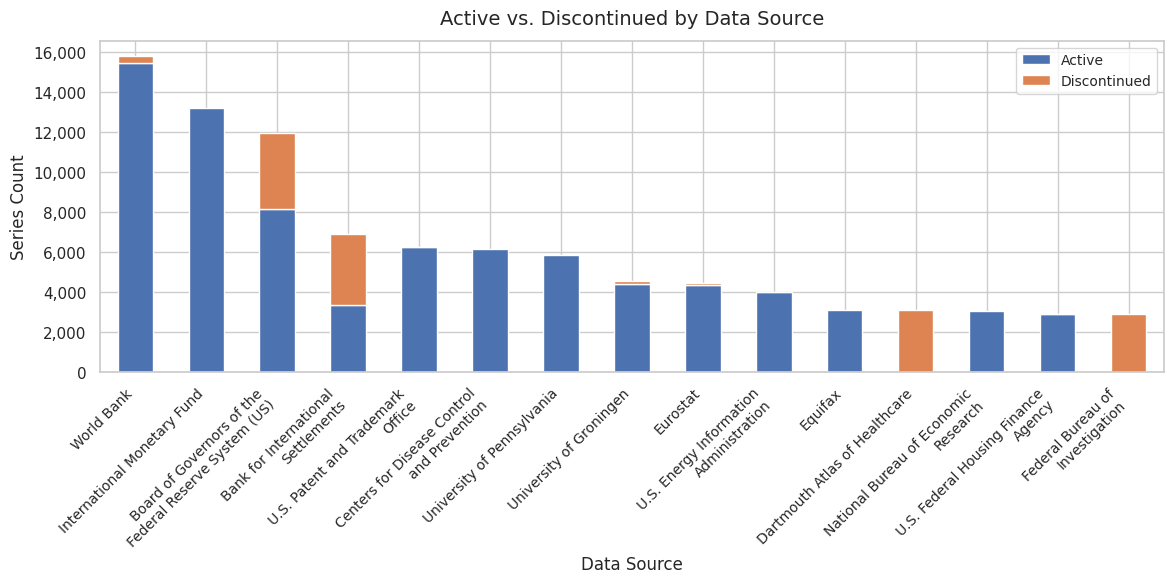

In [19]:
# Prepare data.
nd_sources = fred["data_source"].value_counts().head(20).index.tolist()[5:]
ds_top20 = ds.reindex(nd_sources).fillna(0)
wrapped_labels = [textwrap.fill(src, width=30) for src in nd_sources]
# Plot.
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
ds_top20.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["C0", "C1"],  # blue=active, orange=discontinued
    edgecolor="white",
    linewidth=1,
    legend=True,
)
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right", fontsize=10)
ax.set_xlabel("Data Source", fontsize=12)
ax.set_ylabel("Series Count", fontsize=12)
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
ax.set_title("Active vs. Discontinued by Data Source", fontsize=14, pad=12)
ax.legend(["Active", "Discontinued"], title="", loc="upper right", fontsize=10)
fig.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

<a name='top-20-discontinued-by-data-source'></a>
### Top 20 Discontinued by Data Source

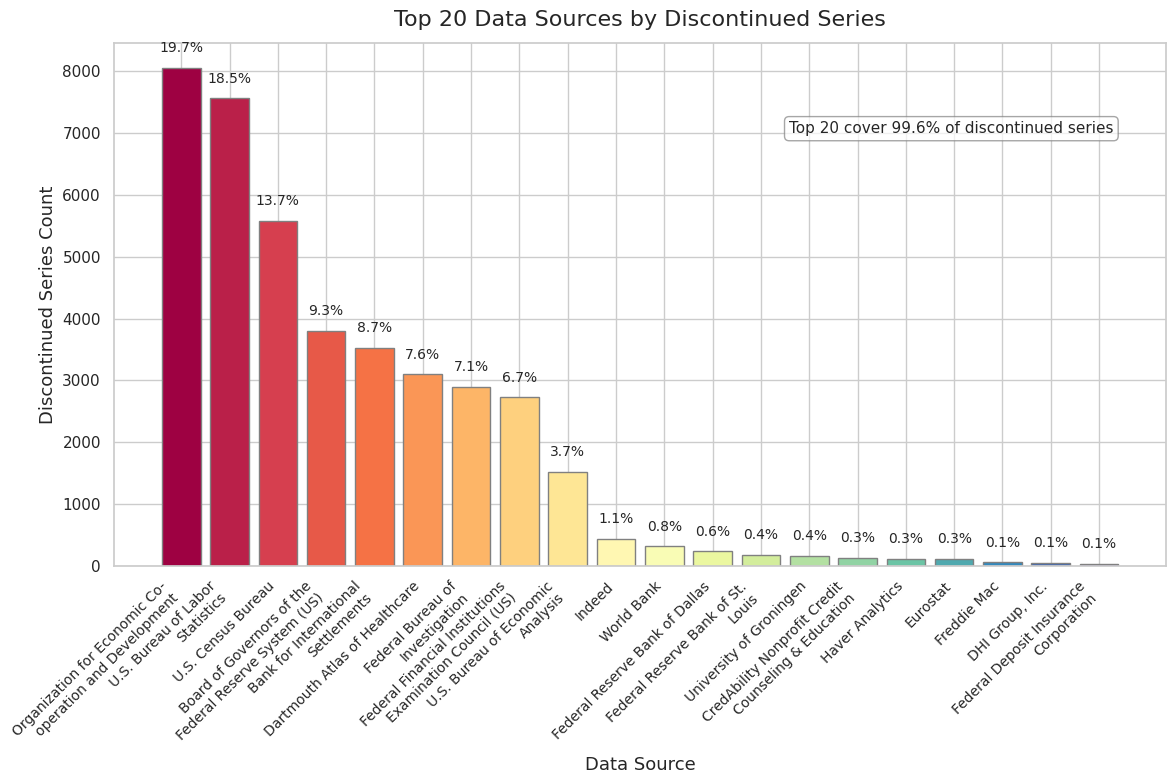

In [20]:
# Prepare data.
N = 20
total_disc = fred["is_discontinued"].sum()
disc_src = fred.loc[fred["is_discontinued"], "data_source"].value_counts().head(N)
labels_src = [textwrap.fill(lbl, width=30) for lbl in disc_src.index]
coverage_src = disc_src.sum() / total_disc * 100
# Plot.
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
x = np.arange(len(disc_src))
colors = plt.cm.Spectral(np.linspace(0, 1, N))
bars = ax.bar(x, disc_src.values, color=colors, edgecolor="gray", linewidth=1)
# Annotate.
for bar, cnt in zip(bars, disc_src.values):
    pct = cnt / total_disc * 100
    ax.text(
        bar.get_x() + bar.get_width() * 0.5,
        cnt + total_disc * 0.005,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_xticks(x)
ax.set_xticklabels(labels_src, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Discontinued Series Count", fontsize=13)
ax.set_xlabel("Data Source", fontsize=13)
ax.set_title(f"Top {N} Data Sources by Discontinued Series", fontsize=16, pad=12)
ax.text(
    0.95,
    0.85,
    f"Top {N} cover {coverage_src:.1f}% of discontinued series",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)
plt.tight_layout()
plt.show()

<a name='top-20-discontinued-by-tag'></a>
### Top 20 Discontinued by Tag

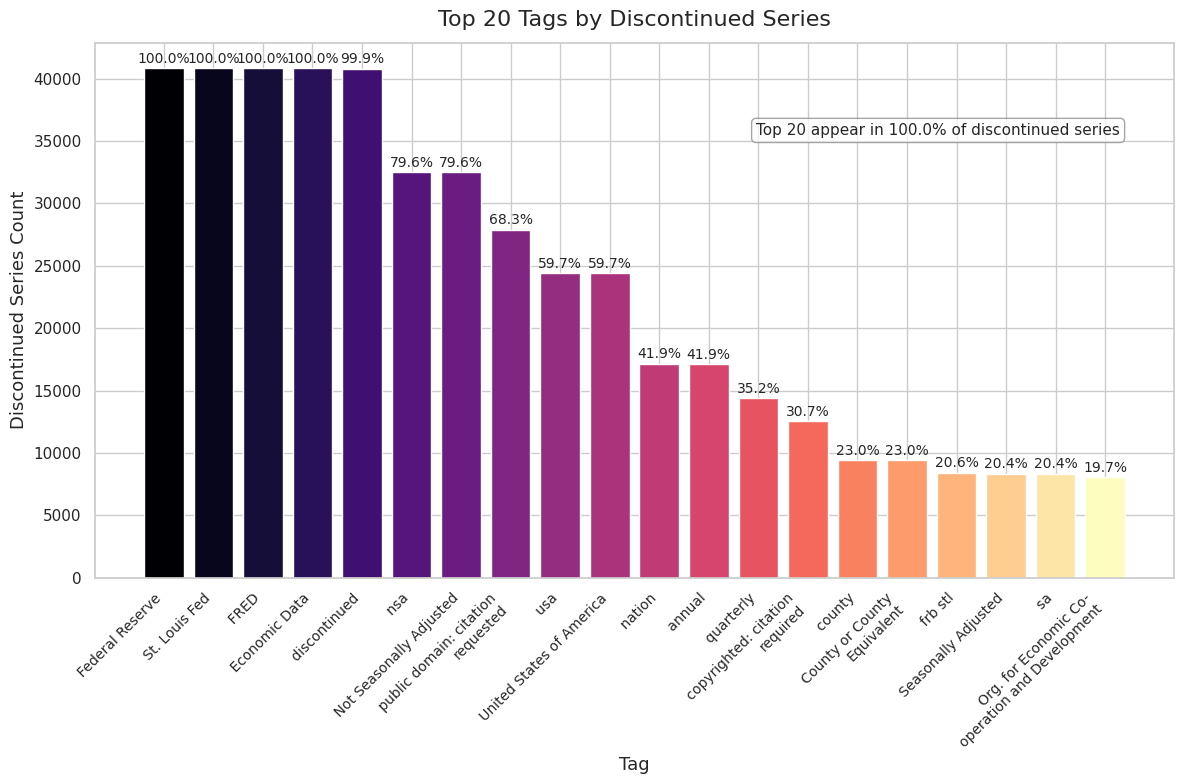

In [21]:
# Prepare data.
disc_tag_series = (
    fred.loc[fred["is_discontinued"], ["id", "tags_list"]]
    .explode("tags_list")
    .dropna(subset=["tags_list"])
)
disc_tags = (
    disc_tag_series.groupby("tags_list")["id"]
    .nunique()
    .sort_values(ascending=False)
    .head(N)
)
top_tag_set = set(disc_tags.index)
disc_series = fred.loc[fred["is_discontinued"]]
has_top_tag = disc_series["tags_list"].apply(
    lambda tags: any(t in top_tag_set for t in (tags or []))
)
coverage_tag = has_top_tag.sum() / total_disc * 100
labels_tag = [textwrap.fill(lbl, width=25) for lbl in disc_tags.index]
# Plot.
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
x = np.arange(len(disc_tags))
colors = plt.cm.magma(np.linspace(0, 1, N))
bars = ax.bar(x, disc_tags.values, color=colors, edgecolor="white", linewidth=1)
for bar, cnt in zip(bars, disc_tags.values):
    pct = cnt / total_disc * 100
    ax.text(
        bar.get_x() + bar.get_width() * 0.5,
        cnt + total_disc * 0.005,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_xticks(x)
ax.set_xticklabels(labels_tag, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Discontinued Series Count", fontsize=13)
ax.set_xlabel("Tag", fontsize=13)
ax.set_title(f"Top {N} Tags by Discontinued Series", fontsize=16, pad=12)
ax.text(
    0.95,
    0.85,
    f"Top {N} appear in {coverage_tag:.1f}% of discontinued series",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)
plt.tight_layout()
plt.show()

<a name='top-20-discontinued-by-category'></a>
### Top 20 Discontinued by Category

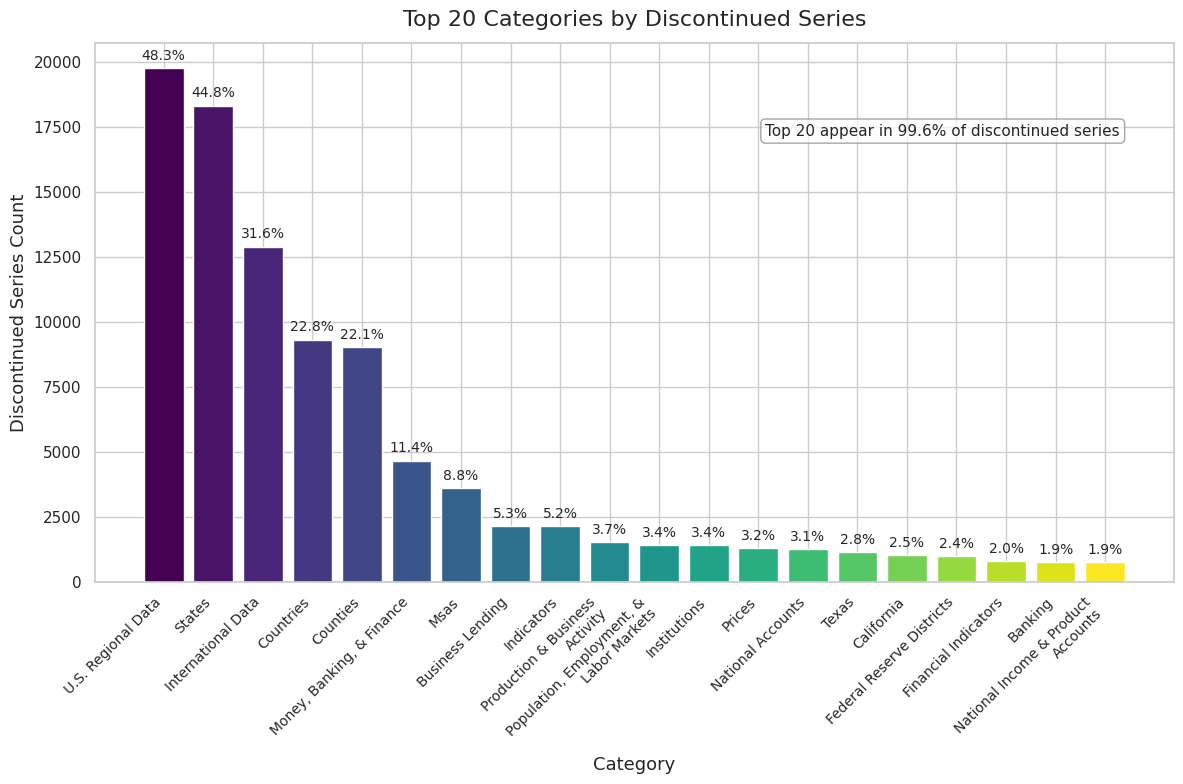

In [22]:

# Prepare data.
disc_cat_series = (
    fred.loc[fred["is_discontinued"], ["id", "categories_list"]]
    .explode("categories_list")
    .dropna(subset=["categories_list"])
)
disc_cats = (
    disc_cat_series.groupby("categories_list")["id"]
    .nunique()
    .sort_values(ascending=False)
    .head(N)
)
top_cat_set = set(disc_cats.index)
has_top_cat = disc_series["categories_list"].apply(
    lambda cats: any(c in top_cat_set for c in (cats or []))
)
coverage_cat = has_top_cat.sum() / total_disc * 100

labels_cat = [textwrap.fill(lbl, width=25) for lbl in disc_cats.index]
# Plot.
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
x = np.arange(len(disc_cats))
colors = plt.cm.viridis(np.linspace(0, 1, N))
bars = ax.bar(x, disc_cats.values, color=colors, edgecolor="white", linewidth=1)
for bar, cnt in zip(bars, disc_cats.values):
    pct = cnt / total_disc * 100
    ax.text(
        bar.get_x() + bar.get_width() * 0.5,
        cnt + total_disc * 0.005,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_xticks(x)
ax.set_xticklabels(labels_cat, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Discontinued Series Count", fontsize=13)
ax.set_xlabel("Category", fontsize=13)
ax.set_title(f"Top {N} Categories by Discontinued Series", fontsize=16, pad=12)
ax.text(
    0.95,
    0.85,
    f"Top {N} appear in {coverage_cat:.1f}% of discontinued series",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)
plt.tight_layout()
plt.show()

- A small set of sources drive most discontinuations:
  - **Organization for Economic Co‑operation and Development** alone accounts for **19.7%** of all discontinuations.
  - The **U.S. Bureau of Labor Statistics** and **U.S. Census Bureau** contribute another **18.5%** and **13.7%**, respectively.
- The top 20 sources cover **99.6%** of all discontinued series, meaning almost every discontinuation comes from one of these 20 providers.

- Over **48%** of discontinued series fall under **U.S. Regional Data**, with **States** adding another **44.8%**.
- Together, the top three categories (including **International Data**) cover over **85%** of discontinuations.
- The top 20 categories collectively appear in **98.4%** of all discontinued series.


- The handful of tags at the top (e.g. **Federal Reserve**, **St. Louis Fed**, **FRED**) each appear in nearly **100%** of all discontinued series, indicating that most discontinued observations share the same metadata tags.
- Beyond the very top tags, coverage drops: the 6th–7th most common (“nsa”, “public domain: citation requested”) appear in about **80%** of discontinued series.
- The top 20 tags collectively appear in **100%** of discontinued series, so almost every discontinued series carries at least one of these 20 tags.


<a name='frequency-of-data'></a>
### Frequency of Data

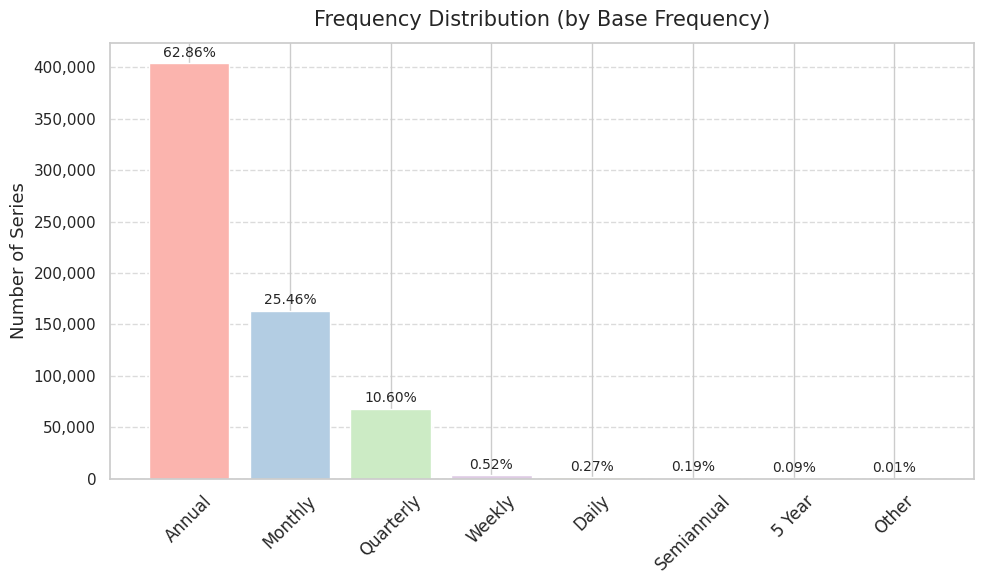

In [23]:
# Prepare Data.
freq_counts = fred["freq_base"].value_counts()
threshold = 100
major = freq_counts[freq_counts >= threshold]
minor_sum = int(freq_counts[freq_counts < threshold].sum())
counts = pd.concat([major, pd.Series({"Other": minor_sum})])
counts = counts.sort_values(ascending=False)
labels = counts.index.tolist()
values = counts.values
total = values.sum()
x_pos = np.arange(len(labels))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(labels)))
# Plot.
plt.figure(figsize=(10, 6), dpi=100)
plt.bar(x_pos, values, color=colors, edgecolor="white", linewidth=1)
# Annotate.
for i, v in enumerate(values):
    pct = v / total * 100
    plt.text(
        i, v + total * 0.005, f"{pct:.2f}%", ha="center", va="bottom", fontsize=10
    )
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y):,}"))
plt.xticks(x_pos, labels, rotation=45, fontsize=12)
plt.ylabel("Number of Series", fontsize=13)
plt.title("Frequency Distribution (by Base Frequency)", fontsize=15, pad=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

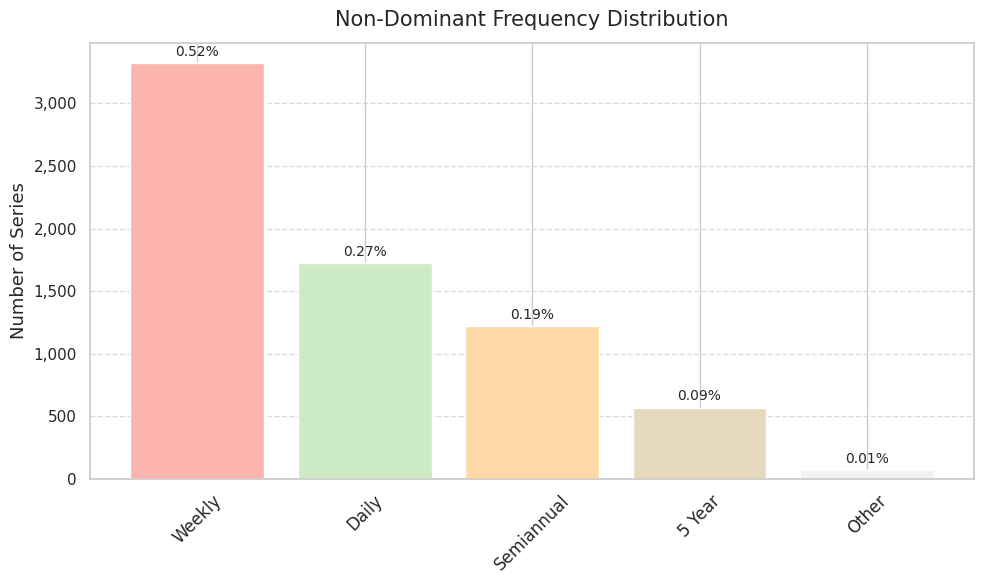

In [24]:
# Prepare data.
threshold = 100
major = freq_counts[freq_counts >= threshold]
minor_sum = int(freq_counts[freq_counts < threshold].sum())
counts = pd.concat([major, pd.Series({"Other": minor_sum})])
counts = counts.sort_values(ascending=False)
counts_nd = counts.drop(counts.index[:3])
labels = counts_nd.index.tolist()
values = counts_nd.values
total = counts.sum()
total_nd = counts_nd.sum()
# Plot.
x_pos = np.arange(len(labels))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(labels)))
plt.figure(figsize=(10, 6), dpi=100)
plt.bar(x_pos, values, color=colors, edgecolor="white", linewidth=1)
# Annotate.
for i, v in enumerate(values):
    pct = v / total * 100
    plt.text(
        i,
        v + total_nd * 0.005,
        f"{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y):,}"))
plt.xticks(x_pos, labels, rotation=45, fontsize=12)
plt.ylabel("Number of Series", fontsize=13)
plt.title("Non‑Dominant Frequency Distribution", fontsize=15, pad=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

<a name='base-frequency-by-data-source'></a>
### Base Frequency by Data Source

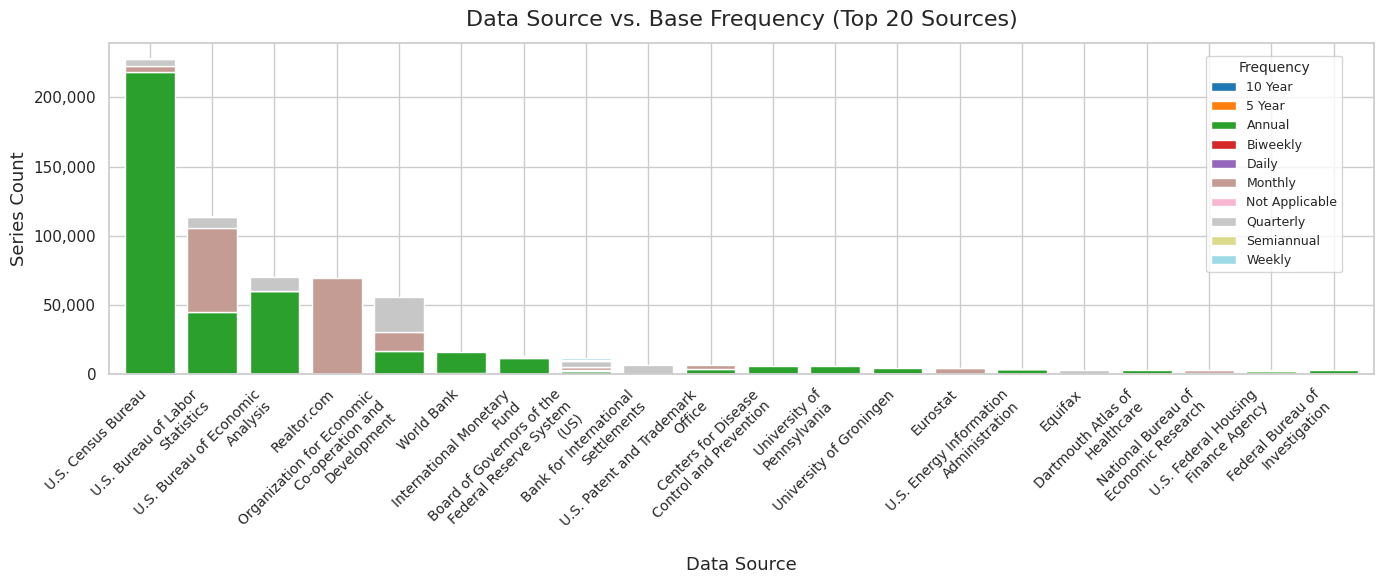

In [25]:
# Prepare data.
top20 = fred["data_source"].value_counts().head(20).index.tolist()
wrapped = [textwrap.fill(lbl, width=25) for lbl in top20]
ct = pd.crosstab(fred["data_source"], fred["freq_base"])
ct = ct.reindex(top20, fill_value=0)
# Plot.
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
ct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8,
    colormap="tab20",
    legend=False,  # we'll add legend inside
)
ax.set_xticks(np.arange(len(wrapped)))
ax.set_xticklabels(wrapped, rotation=45, ha="right", fontsize=10)
ax.set_xlabel("Data Source", fontsize=13)
ax.set_ylabel("Series Count", fontsize=13)
ax.set_title(
    "Data Source vs. Base Frequency (Top 20 Sources)", fontsize=16, pad=12
)
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    title="Frequency",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)
plt.tight_layout()
plt.show()

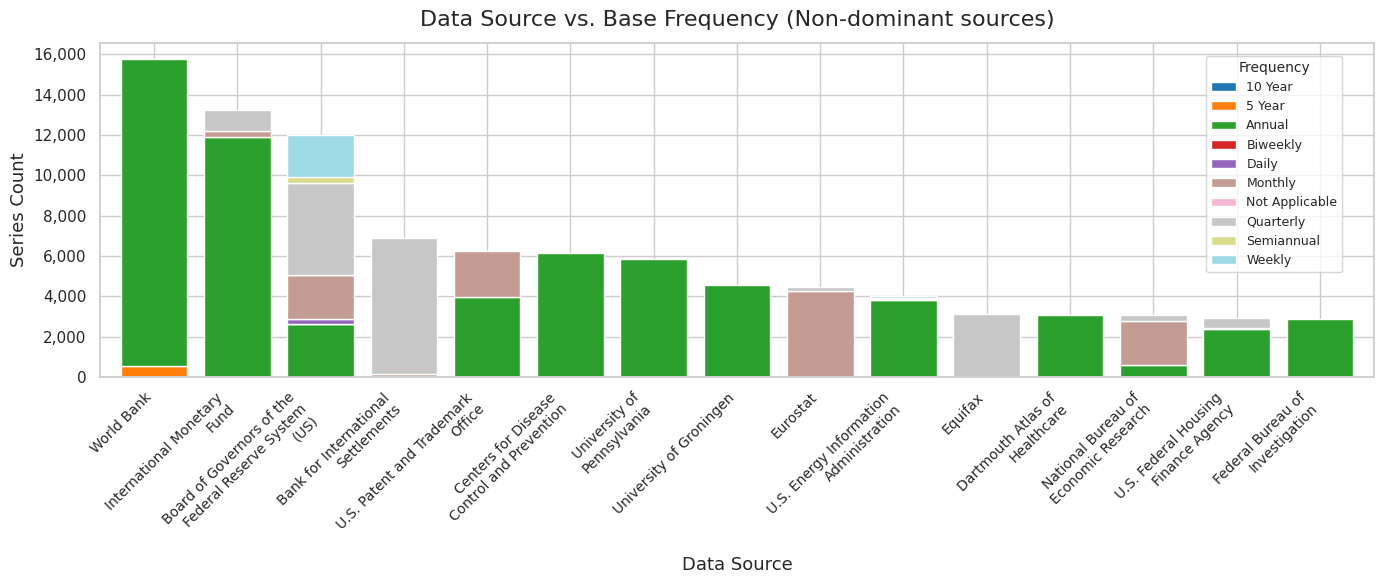

In [26]:
# Prepare data.
top20 = fred["data_source"].value_counts().head(20).index.tolist()
nd_15 = top20[5:]
wrapped = [textwrap.fill(lbl, width=25) for lbl in nd_15]
ct = pd.crosstab(fred["data_source"], fred["freq_base"])
ct = ct.reindex(nd_15, fill_value=0)
# Plot.
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
ct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8,
    colormap="tab20",
    legend=False,  # we'll add legend inside
)
ax.set_xticks(np.arange(len(wrapped)))
ax.set_xticklabels(wrapped, rotation=45, ha="right", fontsize=10)
ax.set_xlabel("Data Source", fontsize=13)
ax.set_ylabel("Series Count", fontsize=13)
ax.set_title(
    "Data Source vs. Base Frequency (Non-dominant sources)", fontsize=16, pad=12
)
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    title="Frequency",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)
plt.tight_layout()
plt.show()

- **Annual, Monthly & Quarterly dominate**
  The full distribution shows that Annual series account for **62.9%** of all data, Monthly for **25.5%**, and Quarterly for **10.6%**, together covering nearly **99%** of the database.

- **Minor frequencies are vanishingly rare**
  Even when grouping all other types (“Weekly”, “Daily”, “Semiannual”, “5 Year” and “Other”) into a single “Other” bucket, they collectively contribute less than **1%** of the total.

- **Zooming in on the non‑dominant slice**
  Removing Annual and Monthly leaves Weekly as the largest of the remainder at **0.52%**, followed by Daily (**0.27%**), Semiannual (**0.19%**), 5 Year (**0.09%**), and Other (**0.01%**).

- **Long‑tail nature of FRED frequencies**
  A tiny handful of base frequencies drive almost the entire series count, with the remaining frequencies forming a very flat, long tail that individually represent only fractions of a percent.


<a name='seasonal-adjustment-analysis'></a>
## Seasonal Adjustment Analysis

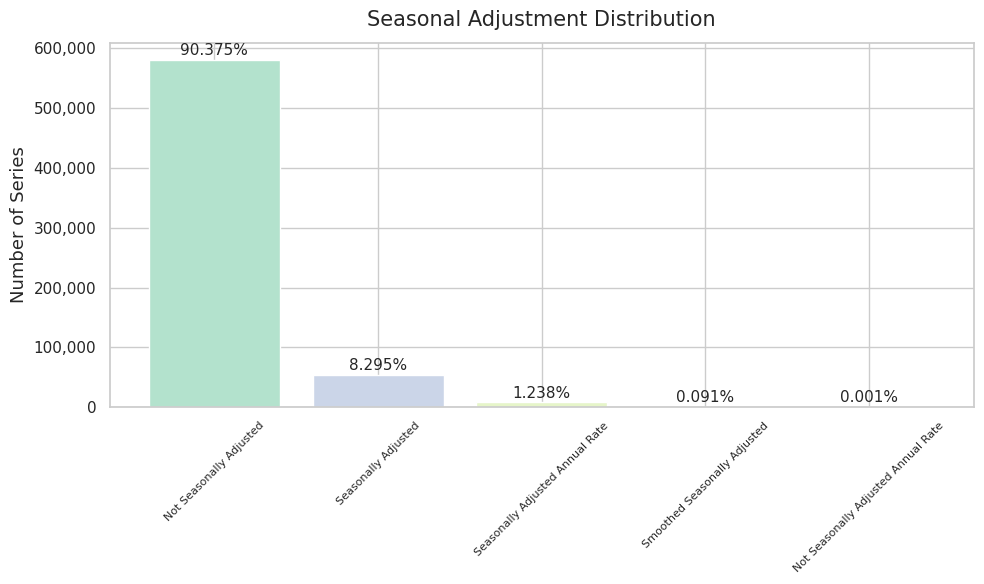

In [27]:
# Prepare data.
sa_counts = fred["seasonal_adjustment"].value_counts()
labels = sa_counts.index.tolist()
sizes = sa_counts.values
total = sizes.sum()
# Plot.
plt.figure(figsize=(10, 6))
colors = plt.cm.Pastel2(np.linspace(0, 1, len(labels)))
x_pos = np.arange(len(labels))
plt.bar(x_pos, sizes, color=colors, edgecolor="white", linewidth=1)
# Annotate.
for i, v in enumerate(sizes):
    pct = v / total * 100
    plt.text(
        i, v + total * 0.005, f"{pct:.3f}%", ha="center", va="bottom", fontsize=11
    )
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y):,}"))
plt.xticks(x_pos, labels, fontsize=8, rotation=45)
plt.ylabel("Number of Series", fontsize=13)
plt.title("Seasonal Adjustment Distribution", fontsize=15, pad=12)
plt.tight_layout()
plt.show()

- **Overwhelming majority unadjusted** – about 90% of series are published “Not Seasonally Adjusted,” indicating raw data is the default for most indicators.
- **Seasonal adjustment still significant** – roughly 8% of series are adjusted for seasonal effects, reflecting key economic indicators (e.g., employment, inflation) where removing seasonal noise is critical.
- **Annual‐rate adjustments rare** – only about 1.2% use a “Seasonally Adjusted Annual Rate” format, and virtually none (<0.1%) employ smoothed or annual‐rate variants, suggesting specialized use cases.
- **Action point** – users seeking trend‐cleansed data will find a modest but not exhaustive selection of seasonally adjusted series; expanding adjustment coverage could benefit comparability across more datasets.

<a name='analyses-on-categories-and-tags'></a>
## Analyses on Categories and Tags

<a name='categories-distribution'></a>
### Categories Distribution

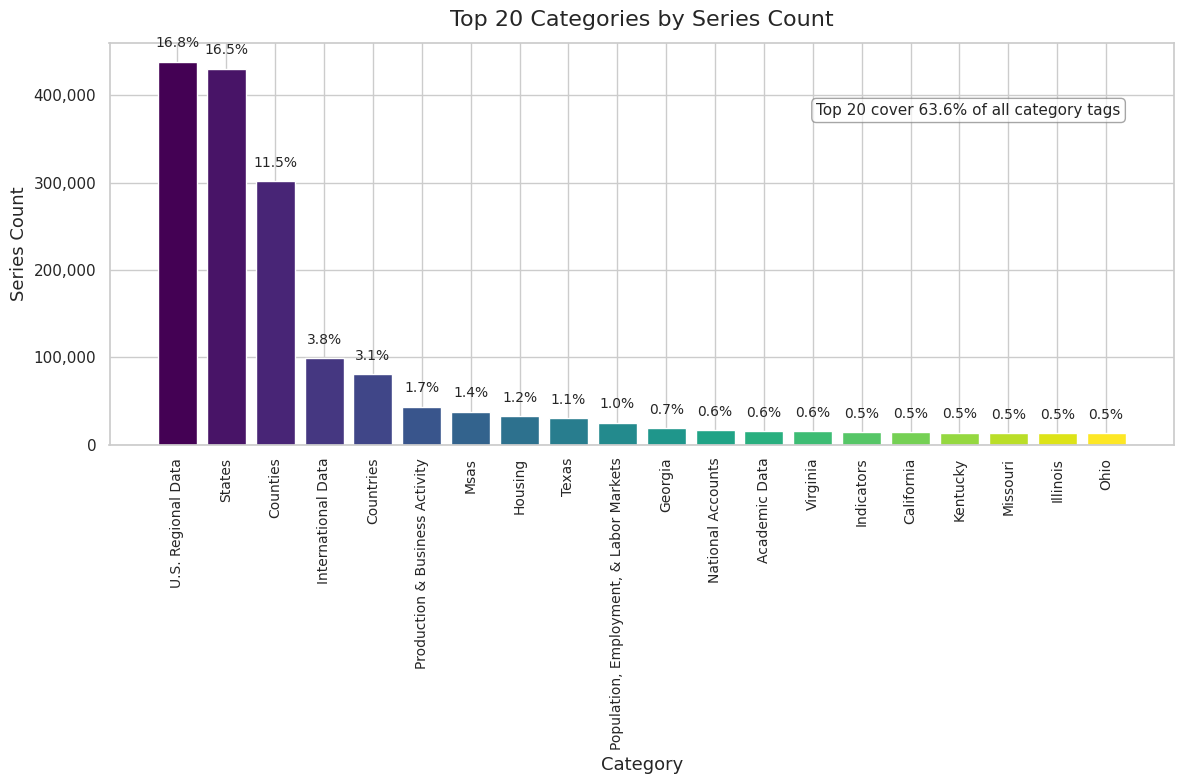

In [28]:
# Compute counts and select top N categories.
N = 20
cat_counts = fred["categories_list"].explode().value_counts()
total_tags = cat_counts.sum()
top_cats = cat_counts.head(N)
coverage_pct = top_cats.sum() / total_tags * 100
# Set up the figure.
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
x = np.arange(len(top_cats))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_cats)))
bars = ax.bar(x, top_cats.values, color=colors, edgecolor="white", linewidth=1)
# Annotate.
for bar in bars:
    height = bar.get_height()
    pct = height / total_tags * 100
    ax.text(
        bar.get_x() + bar.get_width() * 0.5,
        height + total_tags * 0.005,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
# Configure and Format plot.
ax.set_xticks(x)
ax.set_xticklabels(top_cats.index, rotation=90, fontsize=10)
ax.yaxis.set_major_formatter(lambda v, pos: f"{int(v):,}")
ax.set_title(f"Top {N} Categories by Series Count", fontsize=16, pad=12)
ax.set_xlabel("Category", fontsize=13)
ax.set_ylabel("Series Count", fontsize=13)
# Add coverage note.
note = f"Top {N} cover {coverage_pct:.1f}% of all category tags"
ax.text(
    0.95,
    0.85,
    note,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)

plt.tight_layout()
plt.show()

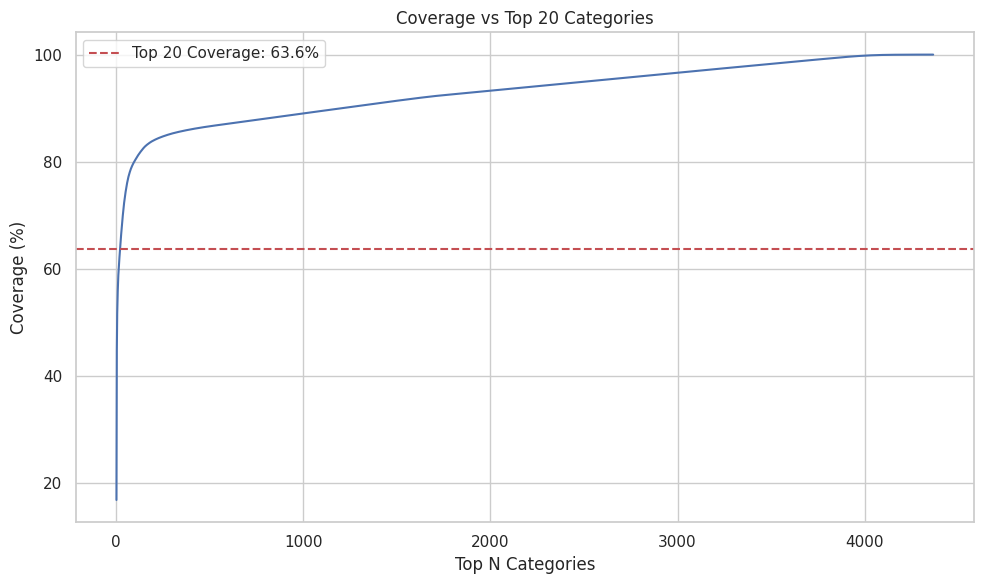

In [29]:
# Compute the cumulative coverage for categories.
cum_coverage = (
    cat_counts.sort_values(ascending=False).cumsum() / cat_counts.sum() * 100
)
# Plot
n_tags = np.arange(1, len(cum_coverage) + 1)
plt.figure(figsize=(10, 6))
plt.plot(n_tags, cum_coverage.values)
plt.axhline(
    cum_coverage.iloc[19],
    color="r",
    linestyle="--",
    label=f"Top {N} Coverage: {cum_coverage.iloc[19]:.1f}%",
)
plt.xlabel(f"Top N Categories")
plt.ylabel("Coverage (%)")
plt.title(f"Coverage vs Top {N} Categories")
plt.legend()
plt.tight_layout()
plt.show()

- **Highly concentrated**
  The top 20 categories account for roughly **63 %** of all category assignments.
  - The single largest category, **U.S. Regional Data**, alone represents nearly 17 % of all series.
  - The next two (**States** and **Counties**) each contribute over 11 %.

- **Long tail**
  Beyond the top 20, coverage climbs very slowly toward 100 % as you include more categories. Thousands of categories are needed before capturing the remaining ~37 % of assignments.

<a name='tags-distribution'></a>
### Tags Distribution

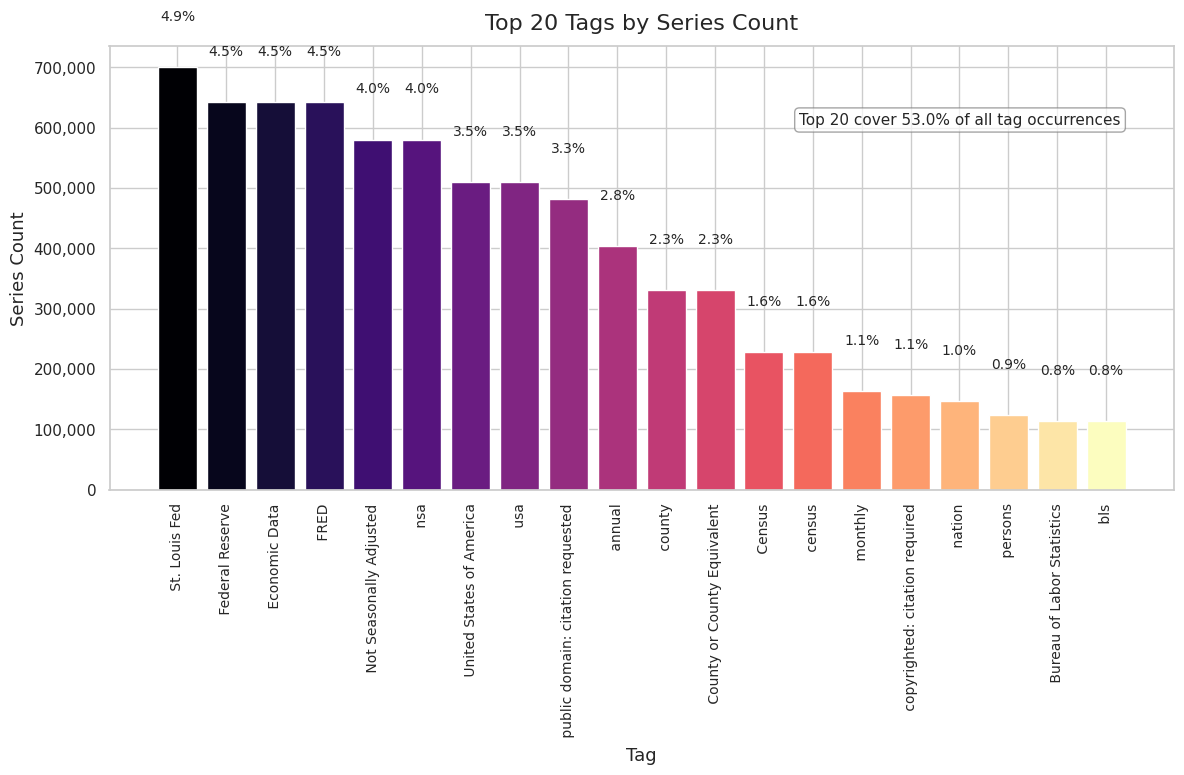

In [30]:
# Compute counts and select top N tags.
N = 20
tag_counts = fred["tags_list"].explode().value_counts()
total_tags = tag_counts.sum()
top_tags = tag_counts.head(N)
coverage_pct = top_tags.sum() / total_tags * 100
# Set up the figure.
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
x = np.arange(len(top_tags))
colors = plt.cm.magma(np.linspace(0, 1, len(top_tags)))
bars = ax.bar(x, top_tags.values, color=colors, edgecolor="white", linewidth=1)
# Annotate.
for bar in bars:
    height = bar.get_height()
    pct = height / total_tags * 100
    ax.text(
        bar.get_x() + bar.get_width() * 0.5,
        height + total_tags * 0.005,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
# Configure and format plot.
ax.set_xticks(x)
ax.set_xticklabels(top_tags.index, rotation=90, fontsize=10)
ax.yaxis.set_major_formatter(lambda v, pos: f"{int(v):,}")
ax.set_title(f"Top {N} Tags by Series Count", fontsize=16, pad=12)
ax.set_xlabel("Tag", fontsize=13)
ax.set_ylabel("Series Count", fontsize=13)
# Add coverage note.
note = f"Top {N} cover {coverage_pct:.1f}% of all tag occurrences"
ax.text(
    0.95,
    0.85,
    note,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)
plt.tight_layout()
plt.show()

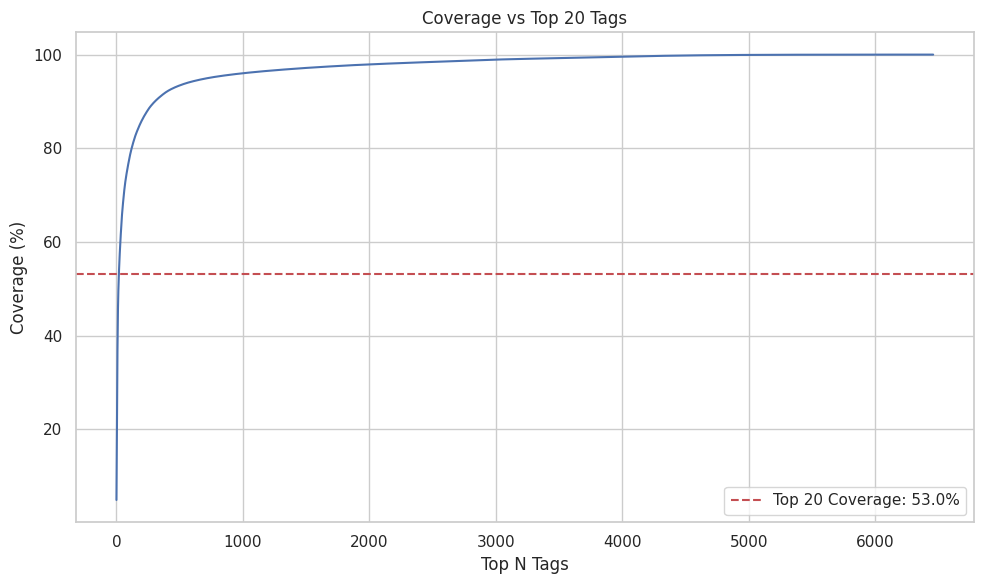

In [31]:
# Compute the cumulative coverage for categories.
cum_coverage = (
    tag_counts.sort_values(ascending=False).cumsum() / tag_counts.sum() * 100
)
# Plot.
n_tags = np.arange(1, len(cum_coverage) + 1)
plt.figure(figsize=(10, 6))
plt.plot(n_tags, cum_coverage.values)
plt.axhline(
    cum_coverage.iloc[19],
    color="r",
    linestyle="--",
    label=f"Top {N} Coverage: {cum_coverage.iloc[19]:.1f}%",
)
plt.xlabel(f"Top N Tags")
plt.ylabel("Coverage (%)")
plt.title(f"Coverage vs Top {N} Tags")
plt.legend()
plt.tight_layout()
plt.show()

- **Moderate concentration**
  The top 20 tags cover about **53 %** of all tag occurrences.
  - Tags like **St. Louis Fed**, **Federal Reserve**, and **Economic Data** each appear on roughly 4–5 % of series.

- **Even longer tail**
  After the first few dozen tags, adding more yields diminishing returns in coverage. Thousands of additional tags must be included to reach beyond ~90 % total coverage.

<a name='count-of-tags-and-categories-per-series'></a>
### Count of Tags and Categories per Series

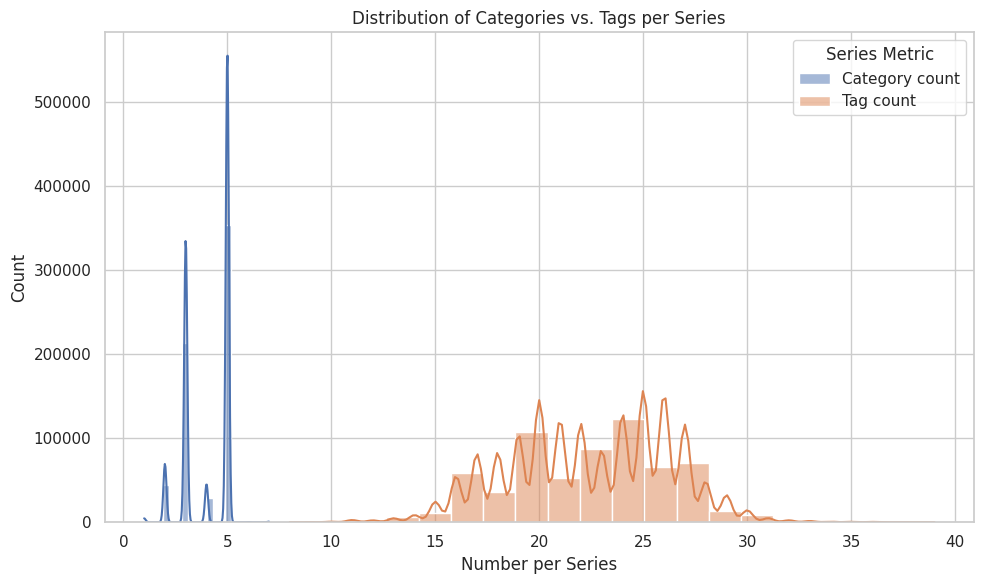

In [32]:
# Plot.
plt.figure(figsize=(10, 6))
sns.histplot(
    fred["n_categories"], bins=20, kde=True, color="C0", label="Category count"
)
sns.histplot(fred["n_tags"], bins=20, kde=True, color="C1", label="Tag count")
plt.legend(title="Series Metric")
plt.title("Distribution of Categories vs. Tags per Series")
plt.xlabel("Number per Series")
plt.tight_layout()
plt.show()

- **Categories are very coarse**
  Most FRED series fall into just 1–6 categories (with a clear spike around 4–5), indicating that the category hierarchy is relatively shallow.

- **Tags are far more granular**
  Tag counts per series cluster around 20–25 and extend past 35, showing that FRED uses tags to capture much finer detail.

<a name='co-occurance-of-the-top-20-tags-with-the-top-20-categories'></a>
### Co-occurance of the Top 20 Tags with the Top 20 Categories

Text(0.5, 1.0, 'Tag–Category Co-occurrence')

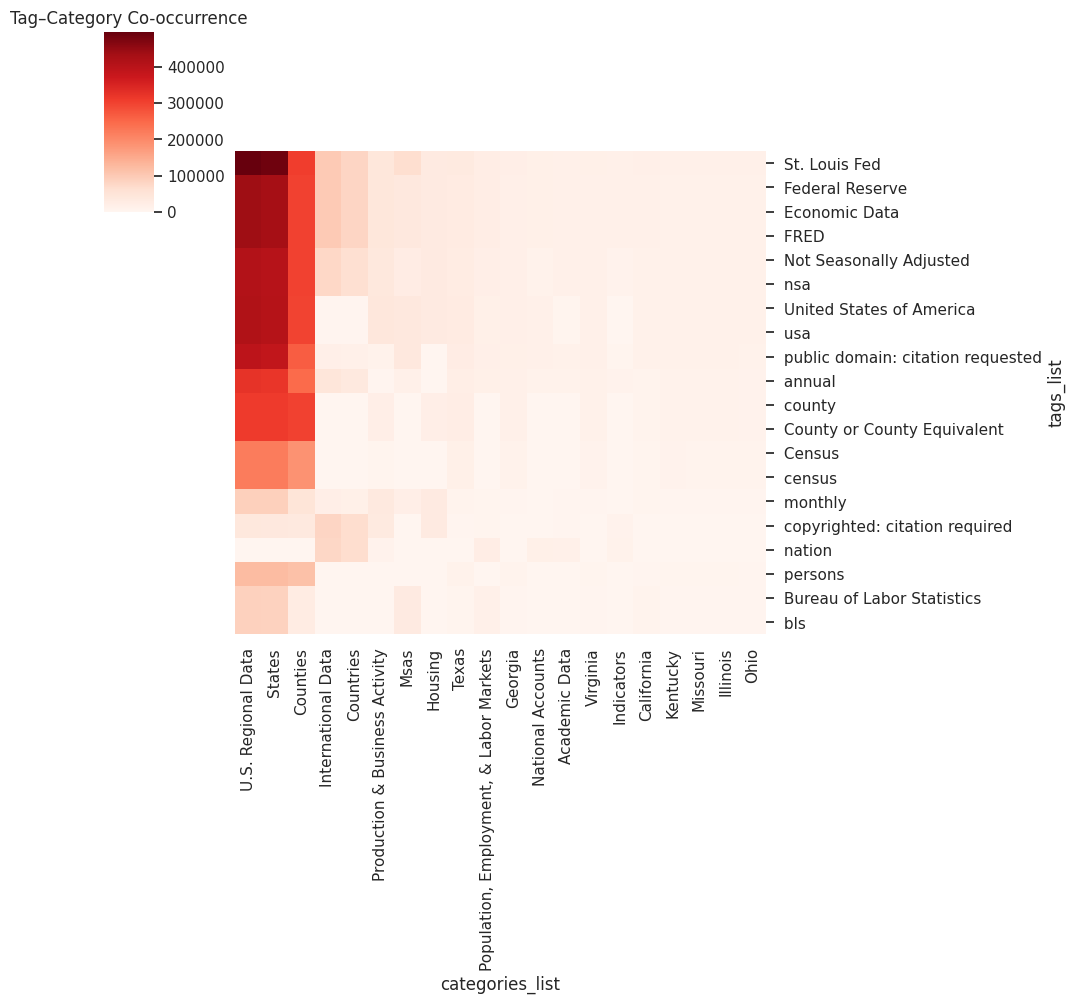

In [33]:
# Prepare data.
top_tags = tag_counts.head(20).index
top_cats = cat_counts.head(20).index
M = pd.DataFrame(0, index=top_tags, columns=top_cats)
for tags, cats in zip(fred["tags_list"], fred["categories_list"]):
    for t in tags or []:
        if t in top_tags:
            for c in cats or []:
                if c in top_cats:
                    M.at[t, c] += 1
# Plot.
sns.clustermap(
    M,
    cmap="Reds",
    row_cluster=False,  # disable clustering of rows
    col_cluster=False,  # disable clustering of columns
)
plt.title("Tag–Category Co-occurrence")

**Insights**

- **Fed‑related tags** (e.g. “St. Louis Fed”, “Federal Reserve”, “FRED”) overwhelmingly co‑occur with the **“U.S. Regional Data”** and **“States”** categories, reflecting that Federal Reserve data is heavily state‑level and regional in scope.
- **Seasonal adjustment tags** (“Not Seasonally Adjusted”, “nsa”) also align almost exclusively with the same U.S.‑regional categories, indicating these series are predominantly regionally reported.
- **Demographic tags** like “county”, “County or County Equivalent”, “Census”, and “census” show strong links to the **“Counties”** and **“Population, Employment, & Labor Markets”** categories, as expected for household and geographic population metrics.
- The **“annual”** and **“persons”** tags—while more diffuse—still peak in categories such as **“International Data”** and **“Production & Business Activity”**, suggesting annual totals and person‑level metrics are used across broader economic indicators.
- **Most tags exhibit very little co‑occurrence outside their primary 1–2 categories**, highlighting that the top tags and categories form clear thematic clusters rather than a highly entangled network.


<a name='geographical-analysis'></a>
## Geographical Analysis

<a name='us-vs-non-us'></a>
### US vs Non-US

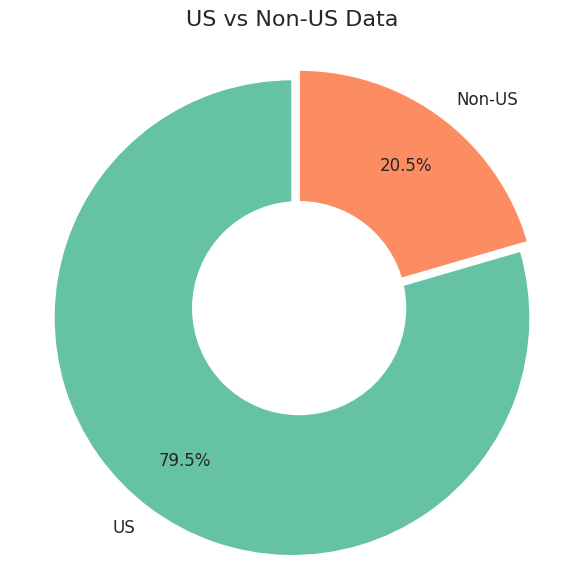

In [34]:
# Prepare data.
pattern = r"\b(?:usa|united states of america)\b"
descriptive_cols = ["tags", "categories", "title", "description", "notes"]
is_us = pd.Series(False, index=fred.index)
for col in descriptive_cols:
    if col in fred.columns:
        is_us |= (
            fred[col].fillna("").str.contains(pattern, case=False, regex=True)
        )
# Count US vs Non‑US series.
counts = is_us.value_counts()
labels = ["US", "Non‑US"]
sizes = [counts.get(True, 0), counts.get(False, 0)]
# Plot.
plt.figure(figsize=(6, 6))
colors = plt.cm.Set2(np.arange(len(sizes)))
explode = (0.05, 0)  # pull out the US slice slightly
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    colors=colors,
    explode=explode,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
    textprops={"fontsize": 12},
)
centre_circle = plt.Circle((0, 0), 0.45, fc="white", linewidth=0)
plt.gca().add_artist(centre_circle)
plt.title("US vs Non‑US Data", fontsize=16, pad=20)
plt.axis("equal")
plt.tight_layout()
plt.show()

<a name='breakdown-by-continent'></a>
### Breakdown by Continent

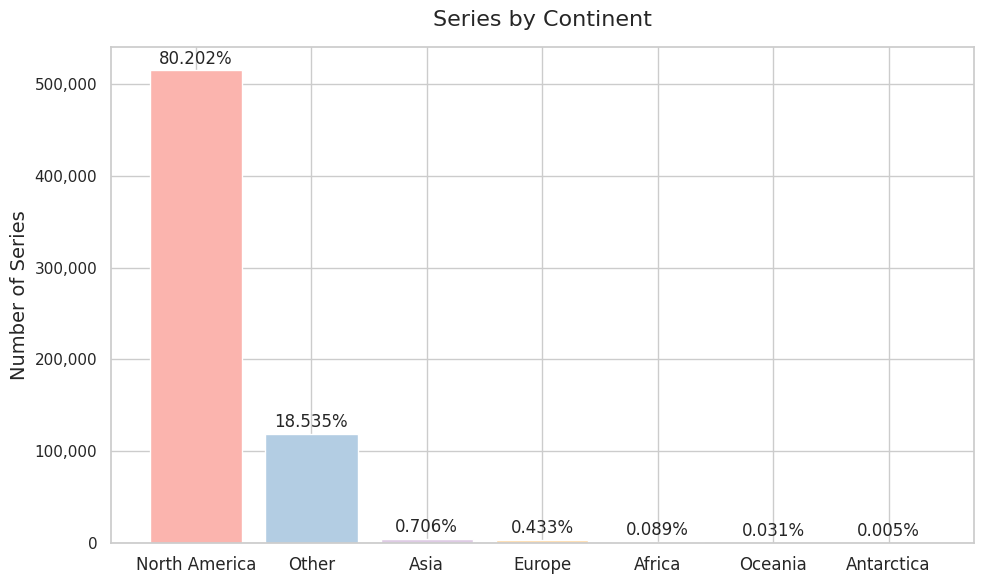

In [35]:
# Prepare Data
cont_counts = fred["continent"].value_counts()
labels = cont_counts.index.tolist()
sizes = cont_counts.values
total = sizes.sum()
# Plot.
plt.figure(figsize=(10, 6))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(labels)))
x_pos = np.arange(len(labels))
plt.bar(x_pos, sizes, color=colors, edgecolor="white", linewidth=1)
# Annotate.
for i, v in enumerate(sizes):
    pct = v / total * 100
    plt.text(
        i, v + total * 0.005, f"{pct:.3f}%", ha="center", va="bottom", fontsize=12
    )
plt.xticks(x_pos, labels, fontsize=12)
plt.ylabel("Number of Series", fontsize=14)
plt.title("Series by Continent", fontsize=16, pad=15)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.tight_layout()
plt.show()

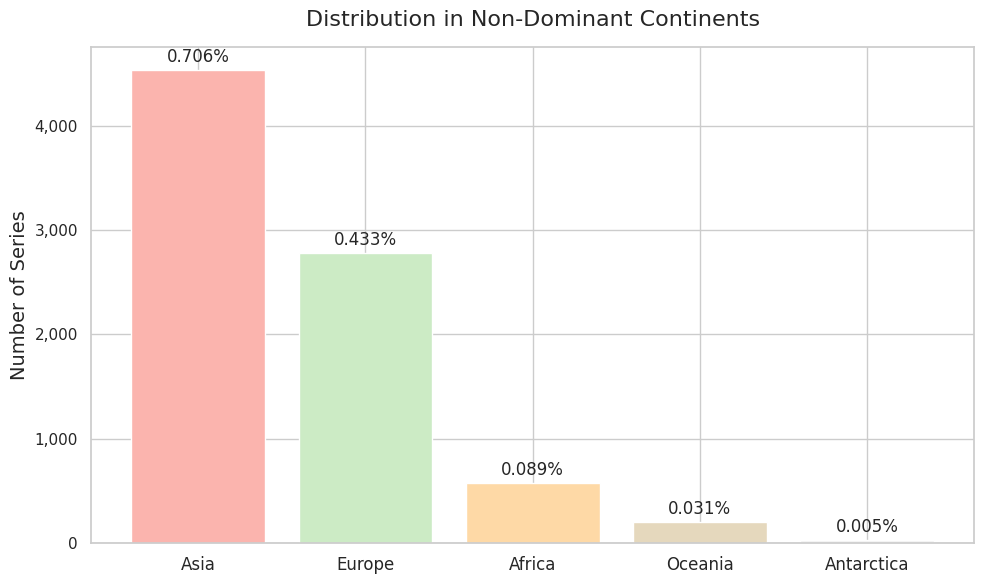

In [36]:
# Prepare Data.
cont_counts_nd = (
    fred["continent"]
    .value_counts()
    .drop(labels=["Other", "North America", np.nan], errors="ignore")
)
labels_nd = cont_counts_nd.index.tolist()
sizes_nd = cont_counts_nd.values
total_nd = sizes_nd.sum()
# Plot.
plt.figure(figsize=(10, 6))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(labels_nd)))
x_pos = np.arange(len(labels_nd))
plt.bar(x_pos, sizes_nd, color=colors, edgecolor="white", linewidth=1)
for i, v in enumerate(sizes_nd):
    pct = v / total * 100
    plt.text(
        i,
        v + total_nd * 0.005,
        f"{pct:.3f}%",
        ha="center",
        va="bottom",
        fontsize=12,
    )
plt.xticks(x_pos, labels_nd, fontsize=12)
plt.ylabel("Number of Series", fontsize=14)
plt.title("Distribution in Non-Dominant Continents", fontsize=16, pad=15)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.tight_layout()
plt.show()

- **Asia Second**
  Besides North America, the most data recorded pertains to Asia, Europe, Africa, Oceania and Anatarctica respectively.


<a name='distribution-of-data-by-state'></a>
### Distribution of Data by State

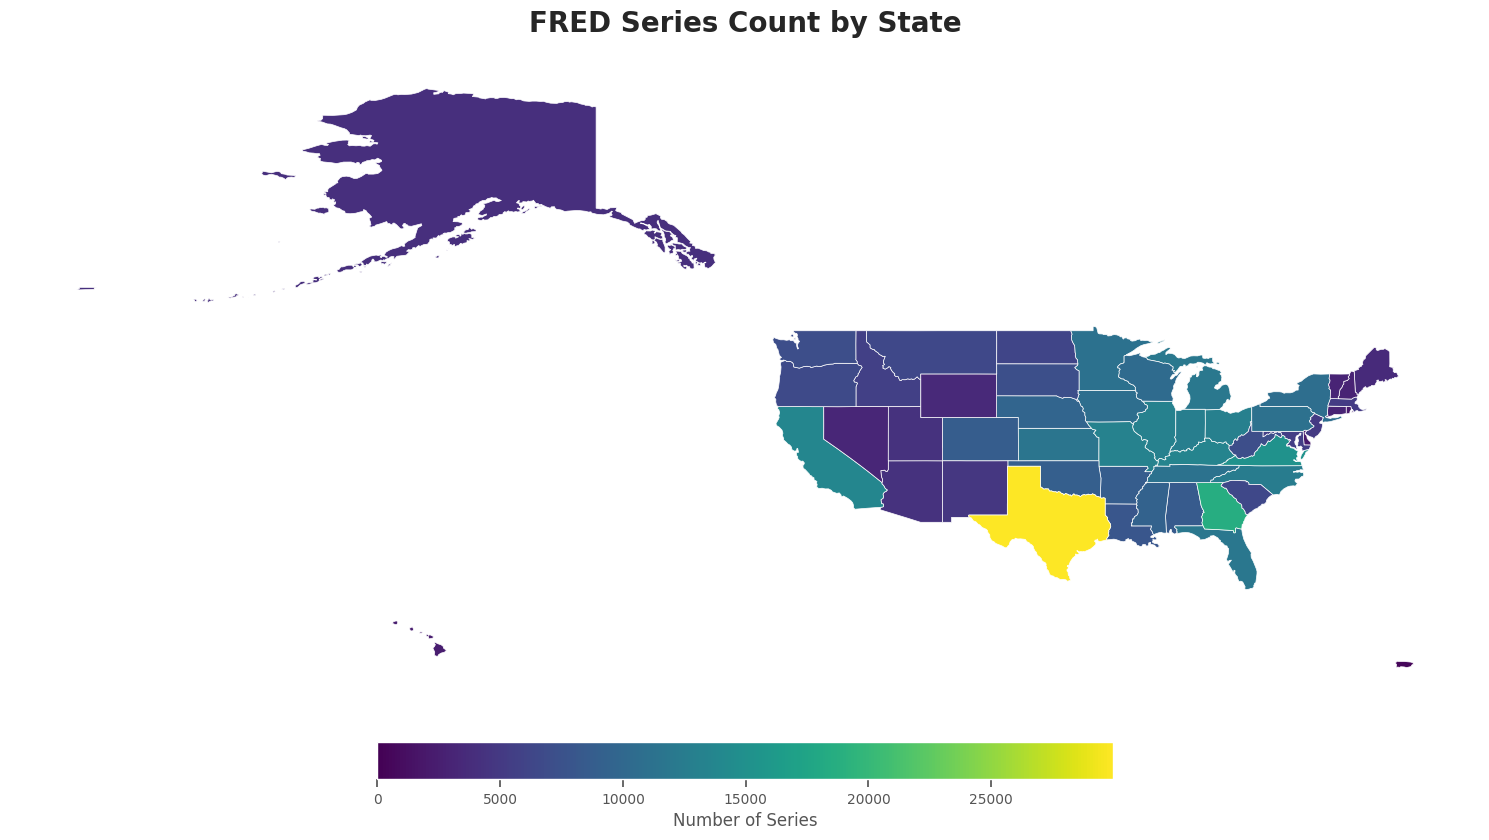

In [39]:

# Prepare data.
raw_counts = fred["categories_list"].explode().value_counts().to_dict()
with open("us_states.geojson") as f:
    geo = json.load(f)
geo_states = {feat["properties"]["name"] for feat in geo["features"]}
state_series = {st: raw_counts.get(st, 0) for st in geo_states}
patches = []
values = []
for feat in geo["features"]:
    name = feat["properties"]["name"]
    count = state_series.get(name, 0)
    geom = feat["geometry"]
    rings = (
        geom["coordinates"]
        if geom["type"] == "Polygon"
        else [r for poly in geom["coordinates"] for r in poly]
    )
    for ring in rings:
        patches.append(Polygon(ring, closed=True))
        values.append(count)
# Plot choropleth map.
plt.style.use("ggplot")  # or remove this line to stick with default
fig, ax = plt.subplots(figsize=(15, 10), dpi=100)
ax.set_facecolor("#f7f7f7")
pc = PatchCollection(
    patches,
    array=np.array(values),
    cmap="viridis",
    norm=plt.Normalize(vmin=0, vmax=max(values)),
    edgecolor="white",
    linewidth=0.5,
)
ax.add_collection(pc)
ax.autoscale_view()
cbar = fig.colorbar(pc, ax=ax, orientation="horizontal", fraction=0.04, pad=0.05)
cbar.set_label("Number of Series", fontsize=12)
cbar.ax.tick_params(labelsize=10)
ax.set_title("FRED Series Count by State", fontsize=20, fontweight="bold", pad=20)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

- **Texas Leads by a Wide Margin**
  Texas stands out with nearly **30,000** series — far more than any other state — reflecting its large and diverse regional datasets.

- **Strong Coverage in Major Economies**
  California (~15K), New York (≈14K), Florida (≈12K) and Georgia (≈20K) all rank in the top tier, consistent with their population size and economic complexity.

- **Moderate Coverage Across the Midwest & Northeast**
  States like Illinois, Ohio, Pennsylvania, Massachusetts and Michigan each host between **8,000–12,000** series, showing solid but less extreme coverage.

- **Sparse Coverage in Rural & Mountain States**
  Many interior and mountain states (e.g., Wyoming, North Dakota, South Dakota, Montana, Vermont) fall below **5,000** series, highlighting regional gaps.

- **Minimal Series in Alaska & Hawai‘i**
  Both non‑contiguous states appear at the low end (< 3,000 series), reflecting fewer localized time‐series data available for those geographies.

Overall, the map shows that FRED’s series are heavily concentrated in the country’s largest and most economically active states, with tapering coverage as populations and economic activity decrease.

<a name='analyses-of-some-derived-features'></a>
## Analyses of some Derived Features

<a name='derived-feature-correlation'></a>
### Derived Feature Correlation

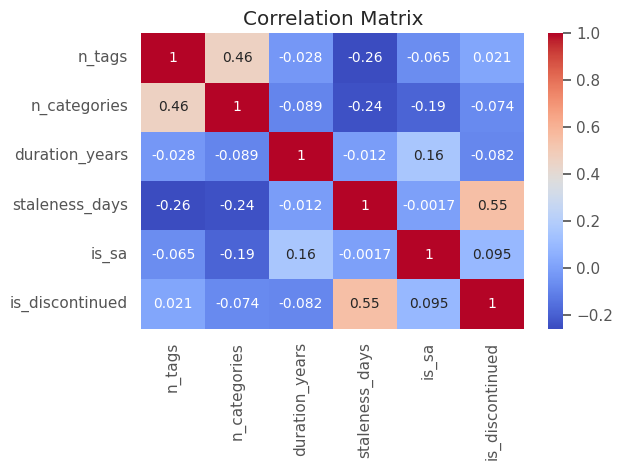

In [40]:
# Prepare data.
num = fred[["n_tags", "n_categories", "duration_years", "staleness_days"]].copy()
num["is_sa"] = (fred["seasonal_adjustment"] != "Not Seasonally Adjusted").astype(
    int
)
num["is_discontinued"] = fred["is_discontinued"].astype(int)
corr = num.corr()
# Plot.
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()

- **Tags & Categories Go Hand‑in‑Hand**
  The number of tags and number of categories a series has are moderately positively correlated (≈ 0.46), suggesting richer metadata tends to appear in tandem.

- **Discontinuation Tracks Staleness**
  “Days since last update” shows a strong positive correlation (≈ 0.55) with the `is_discontinued` flag—series that haven’t been refreshed in a long time are much more likely to be discontinued.

- **Seasonal Adjustment ↔ Longer Durations**
  There’s a small but notable positive link (≈ 0.16) between being seasonally adjusted and having a longer overall span, reflecting that many long‑running datasets apply seasonal filters.

- **Older Series Lose Metadata**
  Slight negative correlations of staleness with both tag count (≈ –0.26) and category count (≈ –0.24) indicate that older, less‑recently updated series tend to accumulate fewer descriptive tags/categories over time.

- **Duration is Largely Independent**
  Total duration in years has near‐zero correlations with both discontinuation and staleness, implying that simply having a long or short history doesn’t by itself predict whether a series is up‑to‑date or active.

<a name='duration-vs-staleness'></a>
### Duration vs Staleness

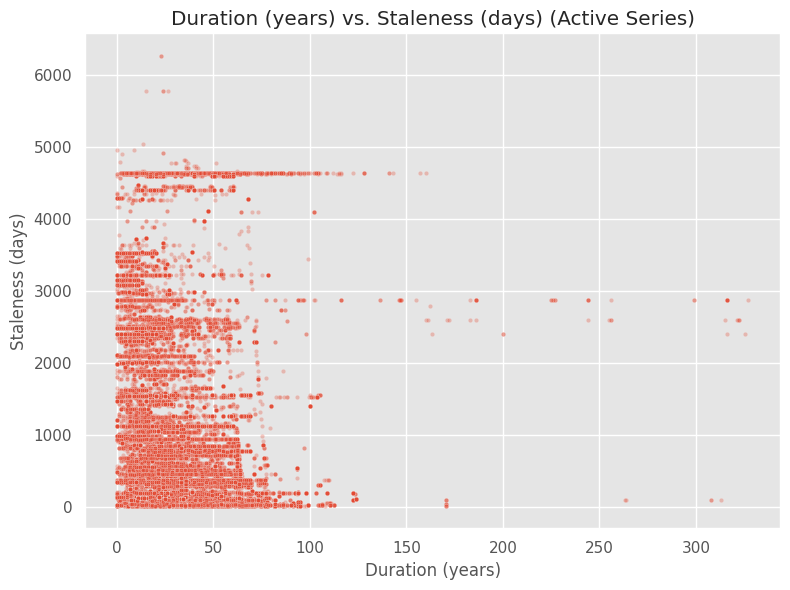

In [41]:
# Prepare data.
active = fred[fred["is_discontinued"] == False]
sample = active.sample(min(len(active), 700000), random_state=1)
# Plot.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="duration_years", y="staleness_days", data=sample, alpha=0.3, s=10
)
plt.title("Duration (years) vs. Staleness (days) (Active Series)")
plt.xlabel("Duration (years)")
plt.ylabel("Staleness (days)")
plt.tight_layout()
plt.show()

- **No clear “longer‑lived = fresher” trend** – series that have run for decades (100+ years) can be either very up‑to‑date or months/years stale, and short‐duration series likewise span the full staleness range.
- **High concentration of moderately stale data** – most series cluster with durations under 50 years and staleness around 0–5 years, indicating routine updates even for long‐running indicators.
- **Freshest series (<30 days old)** are predominantly shorter‐duration (≤20 years), suggesting new or recently rebooted series get updated promptly.
- **Outliers**:
  - A handful of very long‑running series (>200 years) show both extremely low staleness (kept current) and very high staleness (archived).
  - Several mid‑life series (~30–60 years) appear in the 6 000–9 000 days staleness band, highlighting neglected datasets that haven’t been refreshed in a decade or more.